# Multi-Modal Deep Learning for Pancreatic Cancer Detection
## Complete Training Pipeline

**Author:** Leander Antony A  
**Date:** February 2025  

This notebook implements:
1. **Section 1:** Preprocessing + bias/sanity checks (includes **ResNet18 embeddings** and **K-Means k=10** on standardized data)
2. **Section 2:** CT modeling on `ct_cropped` (updated **ResNet50**, **2048-d embeddings**, **K-Means k=2/3/6**, cross-cluster experiments)
3. **Section 3:** Biomarker Classification (MLP)
4. **Section 4:** Multi-Modal Fusion (Feature-level & Decision-level)
5. **Section 5:** Evaluation & Visualization

---

## Section 1 Phase 1: Setup, Data Loading & Preprocessing

In [1]:
# Cell 1.1: Environment + Setup Paths
from __future__ import annotations

import sys
from pathlib import Path

# Make sure the repo root is importable when the notebook is opened from notebooks/
_cwd = Path.cwd().resolve()
_candidates = [_cwd, *_cwd.parents[:4]]
_repo = next((p for p in _candidates if (p / "src").exists() and (p / "reports").exists()), _cwd)
if str(_repo) not in sys.path:
    sys.path.insert(0, str(_repo))

from src.utils import (
    as_path,
    build_project_paths,
    fmt_path,
    require_cols,
    require_nonempty,
    require_path,
    resolve_ct_dir,
    resolve_embeddings_dir,
    resolve_figures_dir,
    resolve_models_dir,
    resolve_reports_dir,
)

PROJECT = build_project_paths(_repo)
PROJ = PROJECT.project_root
DATA_DIR = PROJECT.processed_root
CT_IMAGES = PROJECT.ct_images_dir
CT_INDEX = DATA_DIR / "ct_index_clean.csv"
SPLIT_INDEX = PROJECT.split_index
BIOMARKERS = PROJECT.biomarkers_path
MODELS_DIR = resolve_models_dir(PROJECT)
REPORTS_DIR = resolve_reports_dir(PROJECT)
FIGURES_DIR = resolve_figures_dir(PROJECT)
EMBEDDINGS_DIR = resolve_embeddings_dir(PROJECT)

for directory in [REPORTS_DIR, FIGURES_DIR, MODELS_DIR, EMBEDDINGS_DIR]:
    as_path(directory).mkdir(parents=True, exist_ok=True)

print(f"Project root: {fmt_path(PROJ)}")
print(f"Reports dir : {fmt_path(REPORTS_DIR)}")
print(f"Figures dir : {fmt_path(FIGURES_DIR)}")
print(f"Models dir  : {fmt_path(MODELS_DIR)}")
print(f"Embeddings  : {fmt_path(EMBEDDINGS_DIR)}")



IS_COLAB: False
PROJ: F:\My Drive\Multimodal_Cancer_Detection
✓ CT Index: F:\My Drive\Multimodal_Cancer_Detection\data\processed\ct_index_clean.csv
✓ Split Index: F:\My Drive\Multimodal_Cancer_Detection\data\processed\images_split_index.csv
✓ CT Images (folder): F:\My Drive\Multimodal_Cancer_Detection\data\processed\ct_images


In [40]:
# Cell 1.2: Dependencies

# In Colab, install missing packages quickly. Locally, prefer managing a venv/conda env.
if IS_COLAB:
    import subprocess
    import sys

    subprocess.check_call([
        sys.executable,
        "-m",
        "pip",
        "install",
        "-q",
        "albumentations",
        "scikit-learn",
        "matplotlib",
        "seaborn",
        "tqdm",
        "opencv-python",
        "scipy",
        "scikit-image",
        "torchvision",
    ])
else:
    print("Skipping auto-install (local environment).")
    print("If needed: pip install albumentations scikit-learn matplotlib seaborn tqdm opencv-python scipy scikit-image torchvision")

Skipping auto-install (local environment).
If needed: pip install albumentations scikit-learn matplotlib seaborn tqdm opencv-python scipy scikit-image torchvision


In [41]:
# Cell 1.3: Imports + Reproducibility

# Standard library
import os
import random
import warnings
from pathlib import Path
from collections import defaultdict

# Third-party
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
from tqdm.auto import tqdm

# Torch
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from src.utils import seed_everything

warnings.filterwarnings("ignore")
SEED = 42
seed_everything(SEED)

if torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print(f"Using device: {device}")



Using device: cpu


In [ ]:
# Cell 1.4: Load CT data index
require_path(SPLIT_INDEX, "Split Index")
df_split = pd.read_csv(SPLIT_INDEX)
require_nonempty(df_split, "df_split")
require_cols(df_split, ["split", "label", "patient_id"], "df_split")

# Robust path resolution (works for both local + Colab)
def resolve_image_path(p: str | Path):
    if pd.isna(p):
        return p
    p_str = str(p)

    # If already valid absolute path, keep it
    try:
        p_path = Path(p_str)
        if p_path.exists():
            return str(p_path)
    except Exception:
        pass

    # If Colab Drive path, keep it
    if IS_COLAB and "drive/MyDrive" in p_str.replace("\\", "/"):
        return p_str

    # If it contains ct_images, re-root under our CT_IMAGES folder
    norm = p_str.replace("\\", "/")
    if "ct_images" in norm:
        after = norm.split("ct_images", 1)[1].lstrip("/")
        return str(CT_IMAGES / after)

    # If relative, re-root under PROJ
    if not (":/" in norm or norm.startswith("/")):
        return str((PROJ / norm).resolve())

    return p_str


# Use path_fixed if available, otherwise resolve the path column
if "path_fixed" in df_split.columns:
    src_col = "path_fixed"
elif "path" in df_split.columns:
    src_col = "path"
else:
    raise KeyError("Missing path column in df_split (expected 'path' or 'path_fixed').")
df_split["image_path"] = df_split[src_col].apply(resolve_image_path)


# Verify some paths exist
sample_paths = df_split["image_path"].sample(min(10, len(df_split))).tolist()
valid_count = sum(Path(p).exists() for p in sample_paths)
print(f"Path validation: {valid_count}/{len(sample_paths)} sample paths exist")

if valid_count < max(1, int(0.8 * len(sample_paths))):
    print("WARNING: Many sample paths look invalid. Examples:")
    for p in sample_paths[:3]:
        print(f"  {p} -> exists: {Path(p).exists()}")


# Dataset summary
print(f"\n=== CT Dataset Summary ===")
print(f"Total slices: {len(df_split):,}")
print(f"\nBy split:")
print(df_split.groupby("split")["label"].value_counts().unstack(fill_value=0))
print(f"\nPatients per split:")
print(df_split.groupby("split")["patient_id"].nunique())

## Phase 1B: CRITICAL - Dataset Bias Detection

Before training, we MUST check if the two source datasets (cancer vs control) have different pixel distributions that would allow trivial classification.

In [ ]:
# Cell 1.5: Analyze pixel distributions by dataset source
def analyze_pixel_distributions(df: pd.DataFrame, n_samples: int = 500, random_state: int = SEED):
    """
    Sample images from each class and analyze pixel statistics.
    This detects if datasets have different preprocessing/acquisition.
    """
    stats = {"cancer": [], "control": []}

    for label in ["cancer", "control"]:
        subset_df = df[df["label"] == label]
        if len(subset_df) == 0:
            continue

        subset = subset_df.sample(n=min(n_samples, len(subset_df)), random_state=random_state)

        for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f"Analyzing {label}"):
            img_path = row.get("image_path", None)
            if pd.isna(img_path):
                continue

            img_path = Path(str(img_path))
            if not img_path.exists():
                continue

            img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
            if img is None:
                continue

            img = img.astype(np.float32)
            stats[label].append(
                {
                    "mean": float(img.mean()),
                    "std": float(img.std()),
                    "min": float(img.min()),
                    "max": float(img.max()),
                    "median": float(np.median(img)),
                    "p5": float(np.percentile(img, 5)),
                    "p95": float(np.percentile(img, 95)),
                }
            )

    return {k: pd.DataFrame(v) for k, v in stats.items()}

print("Analyzing pixel distributions (this may take a minute)...")
pixel_stats = analyze_pixel_distributions(df_split, n_samples=300)

In [ ]:
# Cell 1.6: Visualize distribution differences
fig, axes = plt.subplots(2, 3, figsize=(14, 8))

metrics = ["mean", "std", "median", "p5", "p95", "max"]
for ax, metric in zip(axes.flatten(), metrics):
    for label, color in [("cancer", "red"), ("control", "blue")]:
        if len(pixel_stats[label]) > 0:
            ax.hist(
                pixel_stats[label][metric],
                bins=50,
                alpha=0.5,
                label=label,
                color=color,
                density=True,
            )
    ax.set_xlabel(metric)
    ax.set_ylabel("Density")
    ax.legend()
    ax.set_title(f"Pixel {metric} distribution")

plt.suptitle("Dataset Bias Check: Pixel Statistics by Class", fontsize=14)
plt.tight_layout()

out_path = FIGURES_DIR / "dataset_bias_check.png"
plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
plt.show()

# Statistical test for bias
try:
    from scipy import stats as scipy_stats
except ImportError as e:
    raise ImportError("scipy is required here. Install with: pip install scipy") from e

print("\n=== Statistical Tests for Dataset Bias ===")
print("(Large differences indicate the model may learn dataset origin, not cancer features)\n")

for metric in ["mean", "std", "median"]:
    cancer_vals = pixel_stats["cancer"][metric].dropna().values
    control_vals = pixel_stats["control"][metric].dropna().values

    if len(cancer_vals) < 2 or len(control_vals) < 2:
        print(f"{metric.upper()}: insufficient samples for test")
        print()
        continue

    # T-test
    t_stat, p_val = scipy_stats.ttest_ind(cancer_vals, control_vals)

    # Effect size (Cohen's d)
    pooled_std = np.sqrt((cancer_vals.std() ** 2 + control_vals.std() ** 2) / 2)
    if pooled_std == 0:
        cohens_d = np.inf
    else:
        cohens_d = abs(cancer_vals.mean() - control_vals.mean()) / pooled_std

    bias_level = "HIGH" if cohens_d > 0.8 else "MEDIUM" if cohens_d > 0.5 else "LOW"

    print(f"{metric.upper()}:")
    print(f"  Cancer: {cancer_vals.mean():.2f} ± {cancer_vals.std():.2f}")
    print(f"  Control: {control_vals.mean():.2f} ± {control_vals.std():.2f}")
    print(f"  Cohen's d: {cohens_d:.3f} -> Bias level: {bias_level}")
    print(f"  p-value: {p_val:.2e}")
    print()

In [ ]:
# Cell 1.7: Simple classifier on raw pixel mean (sanity check)
# If this works well, we have a dataset bias problem


# Combine stats with labels
cancer_df = pixel_stats["cancer"].copy()
cancer_df["label"] = 1
control_df = pixel_stats["control"].copy()
control_df["label"] = 0

combined = pd.concat([cancer_df, control_df], ignore_index=True).dropna(subset=["mean"])

# Train simple classifier on just pixel mean
X = combined[["mean"]].values
y = combined["label"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y
 )

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)
y_prob = clf.predict_proba(X_test)[:, 1]

acc = accuracy_score(y_test, y_pred)
auc_score = roc_auc_score(y_test, y_prob)

print("=" * 50)

In [ ]:
# Cell 1.8: Compute reference histogram from control dataset
# We'll use control as reference since it typically has more samples

def compute_reference_histogram(
    df: pd.DataFrame, label: str = "control", n_samples: int = 200, random_state: int = SEED
 ):
    """Compute cumulative histogram (CDF) from a reference dataset."""
    all_pixels: list[np.ndarray] = []
    rng = np.random.default_rng(random_state)

    subset_df = df[df["label"] == label]
    subset = subset_df.sample(n=min(n_samples, len(subset_df)), random_state=random_state)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc="Building reference"):
        img_path = row.get("image_path", None)
        if pd.isna(img_path):
            continue
        img_path = Path(str(img_path))
        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        flat = img.reshape(-1)
        if len(flat) == 0:
            continue
        n_pick = min(10_000, len(flat))
        idx = rng.choice(len(flat), size=n_pick, replace=False)
        all_pixels.append(flat[idx])

    if len(all_pixels) == 0:
        raise RuntimeError(f"No pixels collected for reference label='{label}'.")

    all_pixels_np = np.concatenate(all_pixels).astype(np.uint8)

    # Histogram + CDF
    hist, bins = np.histogram(all_pixels_np, bins=256, range=(0, 256), density=True)
    cdf = hist.cumsum()
    cdf = cdf / cdf[-1]
    return cdf, bins

print("Computing reference histogram from control dataset...")
ref_cdf, ref_bins = compute_reference_histogram(df_split, label="control", n_samples=200)
print("Reference histogram computed.")

In [ ]:
# Cell 1.8b: Forced intensity standardization
# This forces BOTH datasets to have identical mean and std (on body pixels)

TARGET_MEAN = 128.0
TARGET_STD = 40.0

def standardize_intensity(img: np.ndarray, target_mean: float = TARGET_MEAN, target_std: float = TARGET_STD) -> np.ndarray:
    """
    Force image to have specific mean/std on body pixels (non-background).
    Intended to reduce scanner-specific intensity differences.
    """
    img_f = img.astype(np.float32)
    body_mask = img_f > 10
    if int(body_mask.sum()) < 100:
        return img_f.astype(np.uint8)

    body_pixels = img_f[body_mask]
    img_mean = float(body_pixels.mean())
    img_std = float(body_pixels.std())
    img_std = max(img_std, 1.0)

    img_new = img_f.copy()
    img_new[body_mask] = (body_pixels - img_mean) / img_std * target_std + target_mean
    img_new = np.clip(img_new, 0, 255)
    return img_new.astype(np.uint8)

# Quick test on samples
print("Testing intensity standardization...")
sample_cancer = df_split[df_split["label"] == "cancer"].sample(n=1, random_state=SEED).iloc[0]
sample_control = df_split[df_split["label"] == "control"].sample(n=1, random_state=SEED).iloc[0]

img_c = cv2.imread(str(sample_cancer["image_path"]), cv2.IMREAD_GRAYSCALE)
img_ctrl = cv2.imread(str(sample_control["image_path"]), cv2.IMREAD_GRAYSCALE)

if img_c is None or img_ctrl is None:
    raise RuntimeError("Could not read sample images for standardization test.")

img_c_std = standardize_intensity(img_c)
img_ctrl_std = standardize_intensity(img_ctrl)

print(f"Cancer  - Before: mean={img_c.mean():.1f}, std={img_c.std():.1f}")
print(f"Cancer  - After:  mean={img_c_std.mean():.1f}, std={img_c_std.std():.1f}")
print(f"Control - Before: mean={img_ctrl.mean():.1f}, std={img_ctrl.std():.1f}")
print(f"Control - After:  mean={img_ctrl_std.mean():.1f}, std={img_ctrl_std.std():.1f}")

In [ ]:
# Cell 1.9: Histogram matching function
def histogram_match(source_img: np.ndarray, ref_cdf: np.ndarray) -> np.ndarray:
    """
    Match histogram of a source image to a reference CDF.
    This normalizes images from different scanners/protocols.
    """
    src_hist, _ = np.histogram(source_img.reshape(-1), bins=256, range=(0, 256), density=True)
    src_cdf = src_hist.cumsum()
    src_cdf = src_cdf / src_cdf[-1]

    lookup = np.zeros(256, dtype=np.uint8)
    for src_val in range(256):
        ref_val = np.searchsorted(ref_cdf, src_cdf[src_val])
        lookup[src_val] = min(int(ref_val), 255)

    return lookup[source_img]

# Test on a sample image
sample_cancer = df_split[df_split["label"] == "cancer"].sample(n=1, random_state=SEED).iloc[0]
sample_control = df_split[df_split["label"] == "control"].sample(n=1, random_state=SEED).iloc[0]

img_cancer = cv2.imread(str(sample_cancer["image_path"]), cv2.IMREAD_GRAYSCALE)
img_control = cv2.imread(str(sample_control["image_path"]), cv2.IMREAD_GRAYSCALE)
if img_cancer is None or img_control is None:
    raise RuntimeError("Could not read sample images for histogram matching demo.")

img_cancer_matched = histogram_match(img_cancer, ref_cdf)

# Visualize
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

axes[0, 0].imshow(img_cancer, cmap="gray")
axes[0, 0].set_title(f"Cancer (original)\nmean={img_cancer.mean():.1f}")
axes[0, 0].axis("off")

axes[0, 1].imshow(img_cancer_matched, cmap="gray")
axes[0, 1].set_title(f"Cancer (matched)\nmean={img_cancer_matched.mean():.1f}")
axes[0, 1].axis("off")

axes[0, 2].imshow(img_control, cmap="gray")
axes[0, 2].set_title(f"Control (reference)\nmean={img_control.mean():.1f}")
axes[0, 2].axis("off")

axes[1, 0].hist(img_cancer.reshape(-1), bins=64, alpha=0.7, color="red")
axes[1, 0].set_title("Cancer histogram (original)")

axes[1, 1].hist(img_cancer_matched.reshape(-1), bins=64, alpha=0.7, color="orange")
axes[1, 1].set_title("Cancer histogram (matched)")

axes[1, 2].hist(img_control.reshape(-1), bins=64, alpha=0.7, color="blue")
axes[1, 2].set_title("Control histogram (reference)")

plt.suptitle("Histogram Matching Example", fontsize=14)
plt.tight_layout()

out_path = FIGURES_DIR / "histogram_matching_example.png"
plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {fmt_path(out_path)}")

In [ ]:
# Cell 1.9b: Re-check bias after forced standardization

print("Re-checking bias after forced intensity standardization...")

std_stats = {"cancer": [], "control": []}

for label in ["cancer", "control"]:
    subset_df = df_split[df_split["label"] == label]
    subset = subset_df.sample(n=min(200, len(subset_df)), random_state=SEED)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f"Checking {label}"):
        img_path = row.get("image_path", None)
        if pd.isna(img_path):
            continue
        img_path = Path(str(img_path))
        if not img_path.exists():
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img_std = standardize_intensity(img)
        std_stats[label].append({"mean": float(img_std.mean()), "std": float(img_std.std())})

# Test classifier on standardized stats
cancer_means = [s["mean"] for s in std_stats["cancer"]]
control_means = [s["mean"] for s in std_stats["control"]]

X_std = np.array(cancer_means + control_means).reshape(-1, 1)
y_std = np.array([1] * len(cancer_means) + [0] * len(control_means))

if len(X_std) < 10 or len(np.unique(y_std)) < 2:
    raise RuntimeError("Not enough samples collected for post-standardization bias check.")

X_tr, X_te, y_tr, y_te = train_test_split(
    X_std, y_std, test_size=0.3, random_state=SEED, stratify=y_std
 )
clf_std = LogisticRegression(max_iter=1000)
clf_std.fit(X_tr, y_tr)
auc_std = roc_auc_score(y_te, clf_std.predict_proba(X_te)[:, 1])

print("\n=== Post-Standardization Bias Check ===")
print(f"AUC from pixel mean alone: {auc_std:.3f}")
print(f"Cancer mean:  {np.mean(cancer_means):.2f} ± {np.std(cancer_means):.2f}")
print(f"Control mean: {np.mean(control_means):.2f} ± {np.std(control_means):.2f}")

if auc_std < 0.65:
    print("\nBias reduced (mean-only AUC < 0.65).")
    USE_STANDARDIZATION = True
else:
    print("\nBias still present (mean-only AUC >= 0.65). Proceed with caution.")
    USE_STANDARDIZATION = True

In [ ]:
# Cell 1.10: Extreme standardization (force identical mean/std)

def extreme_standardize(img):
    """
    Force ALL images to have mean=128, std=40 for body pixels.
    Background forced to exactly 0.
    """
    img = img.astype(np.float32)

    # Body mask - more aggressive threshold
    body_mask = img > 5

    if body_mask.sum() < 100:
        return np.full_like(img, 128, dtype=np.uint8)

    body_pixels = img[body_mask]

    # Force to exact target values
    z_scores = (body_pixels - body_pixels.mean()) / (body_pixels.std() + 1e-8)
    new_pixels = z_scores * 40.0 + 128.0

    # Create output
    img_out = np.zeros_like(img, dtype=np.float32)
    img_out[body_mask] = new_pixels
    img_out = np.clip(img_out, 0, 255)

    return img_out.astype(np.uint8)

# Override the standardize_intensity function
standardize_intensity = extreme_standardize

# Quick test
print("Testing EXTREME standardization...")
test_results = {'cancer': [], 'control': []}

for label in ['cancer', 'control']:
    subset = df_split[df_split['label'] == label].sample(100, random_state=SEED)
    for _, row in subset.iterrows():
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is not None:
            img_std = extreme_standardize(img)
            body = img_std[img_std > 5]
            if len(body) > 0:
                test_results[label].append(body.mean())

c_mean = np.mean(test_results['cancer'])
ctrl_mean = np.mean(test_results['control'])

print(f"Cancer body mean:  {c_mean:.2f}")
print(f"Control body mean: {ctrl_mean:.2f}")
print(f"Difference: {abs(c_mean - ctrl_mean):.2f}")

if abs(c_mean - ctrl_mean) < 5:
    print("✓ Means are now close!")
else:
    print("⚠️ Still different - the datasets have fundamentally different structures")

In [ ]:
# Cell 1.11: Final bias check with extreme standardization

print("Final bias check with extreme standardization...")

final_stats = {'cancer': [], 'control': []}

for label in ['cancer', 'control']:
    subset = df_split[df_split['label'] == label].sample(min(200, len(df_split[df_split['label']==label])), random_state=SEED)

    for _, row in tqdm(subset.iterrows(), total=len(subset), desc=f"Checking {label}"):
        img = cv2.imread(row['image_path'], cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        img_std = extreme_standardize(img)

        # Get stats from body pixels only
        body = img_std[img_std > 5]
        if len(body) > 50:
            final_stats[label].append({
                'mean': body.mean(),
                'std': body.std(),
            })

# Bias test on mean
cancer_means = [s['mean'] for s in final_stats['cancer']]
control_means = [s['mean'] for s in final_stats['control']]

X_final = np.array(cancer_means + control_means).reshape(-1, 1)
y_final = np.array([1]*len(cancer_means) + [0]*len(control_means))

X_tr, X_te, y_tr, y_te = train_test_split(X_final, y_final, test_size=0.3, random_state=SEED, stratify=y_final)
clf_final = LogisticRegression(max_iter=1000)
clf_final.fit(X_tr, y_tr)
auc_mean = roc_auc_score(y_te, clf_final.predict_proba(X_te)[:, 1])

# Also test on std
cancer_stds = [s['std'] for s in final_stats['cancer']]
control_stds = [s['std'] for s in final_stats['control']]

X_std = np.array(cancer_stds + control_stds).reshape(-1, 1)
X_tr_std, X_te_std, y_tr_std, y_te_std = train_test_split(
    X_std,
    y_final,
    test_size=0.3,
    random_state=SEED,
    stratify=y_final
 )
clf_std = LogisticRegression(max_iter=1000)
clf_std.fit(X_tr_std, y_tr_std)
auc_std = roc_auc_score(y_te_std, clf_std.predict_proba(X_te_std)[:, 1])

print(f"\n=== FINAL BIAS CHECK ===")
print(f"AUC from pixel MEAN alone: {auc_mean:.3f}")
print(f"AUC from pixel STD alone:  {auc_std:.3f}")
print(f"\nCancer  - mean: {np.mean(cancer_means):.2f}, std: {np.mean(cancer_stds):.2f}")
print(f"Control - mean: {np.mean(control_means):.2f}, std: {np.mean(control_stds):.2f}")

if auc_mean < 0.65 and auc_std < 0.65:
    print("\n✅ BIAS REMOVED! Safe to proceed with training.")
else:
    print("\n⚠️ Some bias remains but significantly reduced. Proceed with caution.")

In [ ]:
# Cell 1.12: Pre-save standardized images to disk (run once)

STANDARDIZED_DIR = str(DATA_DIR / "ct_standardized")
std_root = Path(STANDARDIZED_DIR)
(std_root / "cancer").mkdir(parents=True, exist_ok=True)
(std_root / "control").mkdir(parents=True, exist_ok=True)

def presave_standardized_images() -> None:
    skipped = 0
    saved = 0
    missing = 0

    for _, row in tqdm(df_split.iterrows(), total=len(df_split), desc="Standardizing images"):
        img_path = Path(str(row["image_path"]))
        if not img_path.exists():
            missing += 1
            continue

        label = str(row["label"])
        patient_id = str(row["patient_id"])
        slice_idx = int(row["slice_idx"])

        out_dir = std_root / label / patient_id
        out_dir.mkdir(parents=True, exist_ok=True)
        out_path = out_dir / f"slice_{slice_idx:03d}.png"

        if out_path.exists():
            skipped += 1
            continue

        img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
        if img is None:
            missing += 1
            continue

        img_std = extreme_standardize(img)
        cv2.imwrite(str(out_path), img_std)
        saved += 1

    print(f"\nDone! Saved: {saved}, Skipped: {skipped}, Missing/unreadable: {missing}")
    print(f"Location: {std_root}")

presave_standardized_images()

---
### Section 1: Phase 1 Summary (Preprocessing, Bias Audit, and Early Unsupervised Structure)

**What we did in Phase 1**
- Verified CT index paths and patient-level splits (train/val/test) before any modeling.
- Applied **extreme intensity standardization** (target mean≈128, std≈40) and ran quick sanity checks to quantify dataset-origin shortcuts.
- Used **ResNet18 as a frozen feature extractor** on the standardized images to obtain initial embeddings.
- Performed **K-Means (k=10)** on those ResNet18 embeddings to characterize early structure *before* filtering/orientation/segmentation/cropping.
- Completed the heavier preprocessing steps (filtering + orientation correction + segmentation/cropping) to produce the final **`ct_cropped`** dataset used for CT training.
- Exported QC artifacts (logs/plots/tables) used later to justify a defensible CT pipeline.

**What comes next (Phase 2)**
- Use **ResNet50** on `ct_cropped` to extract **2048-d embeddings**, then run **K-Means (k=2, 3, 6)** (saving assignments for k=2 and k=3).
- Train/evaluate supervised CT classifiers (ResNet50) and run cross-cluster generalization experiments.
- Save final models + reports for downstream fusion and dissertation figures.
---

---
## Section 1: Phase 2 CT Image Classification

In this phase we switch to the fully-preprocessed **`ct_cropped`** dataset and run the updated CT pipeline:
- ResNet50 feature extraction (2048-d embeddings)
- Unsupervised clustering (k=2/3/6) + saved assignments (k=2, k=3)
- Supervised CT modeling + patient-level evaluation + cross-cluster tests
---

In [ ]:
# Cell 1.13: Comprehensive dataset analysis (standardized images)
# Run this to understand what we have after standardization

# Resolve standardized root
std_root = Path(STANDARDIZED_DIR) if "STANDARDIZED_DIR" in globals() else (DATA_DIR / "ct_standardized")
std_root = Path(str(std_root))
if not std_root.exists():
    raise FileNotFoundError(
        f"Standardized CT folder not found: {std_root}. Run the standardization step first."
    )

# ============================================
# PART 1: Basic Dataset Structure
# ============================================
cancer_path = std_root / "cancer"
control_path = std_root / "control"

cancer_patients = sorted([p.name for p in cancer_path.iterdir() if p.is_dir()])
control_patients = sorted([p.name for p in control_path.iterdir() if p.is_dir()])

print("=" * 60)
print("DATASET STRUCTURE")
print("=" * 60)
print(f"Cancer patients: {len(cancer_patients)}")
print(f"Control patients: {len(control_patients)}")
print(f"Total patients: {len(cancer_patients) + len(control_patients)}")

# Count slices per patient
cancer_slices = {}
control_slices = {}
for p in cancer_patients:
    files = list((cancer_path / p).glob("*.png"))
    cancer_slices[p] = len(files)
for p in control_patients:
    files = list((control_path / p).glob("*.png"))
    control_slices[p] = len(files)

if len(cancer_slices) > 0:
    print(
        f"\nCancer slices: min={min(cancer_slices.values())}, max={max(cancer_slices.values())}, mean={np.mean(list(cancer_slices.values())):.1f}"
    )
if len(control_slices) > 0:
    print(
        f"Control slices: min={min(control_slices.values())}, max={max(control_slices.values())}, mean={np.mean(list(control_slices.values())):.1f}"
    )

# ============================================
# PART 2: Visual Grid - ALL Patients
# ============================================
def get_middle_slice(patient_path: Path):
    """Load middle slice from patient folder"""
    files = sorted(list(patient_path.glob("*.png")))
    if len(files) == 0:
        return None
    mid_file = files[len(files) // 2]
    img = cv2.imread(str(mid_file), cv2.IMREAD_GRAYSCALE)
    return img

# Create grid for CANCER patients
n_cancer = len(cancer_patients)
cols = 11
rows = (n_cancer + cols - 1) // cols if n_cancer > 0 else 1

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 2))
fig.suptitle(f"CANCER PATIENTS - Middle Slice (n={n_cancer})", fontsize=16, fontweight="bold")
axes = np.array(axes).reshape(rows, cols)

for idx, patient in enumerate(cancer_patients):
    row, col = idx // cols, idx % cols
    img = get_middle_slice(cancer_path / patient)
    if img is not None:
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(patient.replace("Pancreas-CT-CB_", ""), fontsize=8)
    axes[row, col].axis("off")

for idx in range(n_cancer, rows * cols):
    row, col = idx // cols, idx % cols
    axes[row, col].axis("off")

plt.tight_layout()
out_path = FIGURES_DIR / "all_cancer_patients.png"
plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {fmt_path(out_path)}")

# Create grid for CONTROL patients
n_control = len(control_patients)
rows = (n_control + cols - 1) // cols if n_control > 0 else 1

fig, axes = plt.subplots(rows, cols, figsize=(22, rows * 2))
fig.suptitle(f"CONTROL PATIENTS - Middle Slice (n={n_control})", fontsize=16, fontweight="bold")
axes = np.array(axes).reshape(rows, cols)

for idx, patient in enumerate(control_patients):
    row, col = idx // cols, idx % cols
    img = get_middle_slice(control_path / patient)
    if img is not None:
        axes[row, col].imshow(img, cmap="gray")
        axes[row, col].set_title(patient.replace("PANCREAS_", ""), fontsize=8)
    axes[row, col].axis("off")

for idx in range(n_control, rows * cols):
    row, col = idx // cols, idx % cols
    axes[row, col].axis("off")

plt.tight_layout()
out_path = FIGURES_DIR / "all_control_patients.png"
plt.savefig(str(out_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {fmt_path(out_path)}")

In [ ]:
# Cell 1.14: Statistical analysis of all patients (standardized images)

# Resolve standardized folder (created earlier in Phase 1)
std_root = Path(STANDARDIZED_DIR) if "STANDARDIZED_DIR" in globals() else (DATA_DIR / "ct_standardized")
if not std_root.exists():
    raise FileNotFoundError(
        f"Standardized CT folder not found: {std_root}. Run the standardization step first."
    )

def analyze_patient(patient_path: Path) -> dict:
    """Analyze a small, evenly spaced sample of slices from a patient folder."""
    files = sorted([p for p in patient_path.iterdir() if p.is_file()])
    if len(files) == 0:
        return {
            "n_slices": 0,
            "mean_body_ratio": 0.0,
            "mean_intensity": 0.0,
            "std_intensity": 0.0,
            "table_top_pct": 0.0,
            "table_bottom_pct": 0.0,
        }

    stats = {
        "n_slices": len(files),
        "body_ratios": [],
        "means": [],
        "stds": [],
        "table_top": [],
        "table_bottom": [],
    }

    # Sample up to 5 slices evenly spaced across the volume
    sample_indices = np.linspace(0, len(files) - 1, min(5, len(files)), dtype=int)
    for idx in sample_indices:
        img = cv2.imread(str(files[idx]), cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue

        body_mask = img > 10
        body_ratio = float(np.sum(body_mask) / img.size)

        # Heuristic: scanner table bright strip at extreme edges
        top_strip = img[:20, :]
        bottom_strip = img[-20:, :]
        table_top = float(np.mean(top_strip) > 30)
        table_bottom = float(np.mean(bottom_strip) > 30)

        if np.sum(body_mask) > 0:
            stats["means"].append(float(np.mean(img[body_mask])))
            stats["stds"].append(float(np.std(img[body_mask])))
        stats["body_ratios"].append(body_ratio)
        stats["table_top"].append(table_top)
        stats["table_bottom"].append(table_bottom)

    return {
        "n_slices": stats["n_slices"],
        "mean_body_ratio": float(np.mean(stats["body_ratios"])) if stats["body_ratios"] else 0.0,
        "mean_intensity": float(np.mean(stats["means"])) if stats["means"] else 0.0,
        "std_intensity": float(np.mean(stats["stds"])) if stats["stds"] else 0.0,
        "table_top_pct": float(np.mean(stats["table_top"])) if stats["table_top"] else 0.0,
        "table_bottom_pct": float(np.mean(stats["table_bottom"])) if stats["table_bottom"] else 0.0,
    }

# Analyze all patients
results = []
for label in ["cancer", "control"]:
    label_dir = std_root / label
    if not label_dir.exists():
        print(f"WARNING: Missing folder: {label_dir}")
        continue

    patients = sorted([p for p in label_dir.iterdir() if p.is_dir()])
    for patient_dir in tqdm(patients, desc=f"Analyzing {label}"):
        stats = analyze_patient(patient_dir)
        stats["patient"] = patient_dir.name
        stats["label"] = label
        results.append(stats)

df = pd.DataFrame(results)
if df.empty:
    raise RuntimeError("No patient statistics computed (no standardized images found).")

# Display summary
print("\n" + "=" * 60)
print("STATISTICAL SUMMARY")
print("=" * 60)
print(
    df.groupby("label").agg(
        {
            "n_slices": ["min", "max", "mean"],
            "mean_body_ratio": ["min", "max", "mean"],
            "mean_intensity": ["min", "max", "mean"],
            "table_top_pct": "mean",
            "table_bottom_pct": "mean",
        }
    ).round(3)
 )

# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
cancer_df = df[df["label"] == "cancer"]
control_df = df[df["label"] == "control"]

axes[0, 0].hist(cancer_df["mean_body_ratio"], bins=15, alpha=0.7, label="Cancer", color="red")
axes[0, 0].hist(control_df["mean_body_ratio"], bins=15, alpha=0.7, label="Control", color="blue")
axes[0, 0].set_title("Body Ratio (% of image that is body)")
axes[0, 0].legend()

axes[0, 1].hist(cancer_df["mean_intensity"], bins=15, alpha=0.7, label="Cancer", color="red")
axes[0, 1].hist(control_df["mean_intensity"], bins=15, alpha=0.7, label="Control", color="blue")
axes[0, 1].set_title("Mean Intensity")
axes[0, 1].legend()

axes[0, 2].hist(cancer_df["n_slices"], bins=15, alpha=0.7, label="Cancer", color="red")
axes[0, 2].hist(control_df["n_slices"], bins=15, alpha=0.7, label="Control", color="blue")
axes[0, 2].set_title("Number of Slices per Patient")
axes[0, 2].legend()

axes[1, 0].bar(
    ["Cancer\nTable Top", "Cancer\nTable Bottom", "Control\nTable Top", "Control\nTable Bottom"],
    [
        float(cancer_df["table_top_pct"].mean()) if len(cancer_df) else 0.0,
        float(cancer_df["table_bottom_pct"].mean()) if len(cancer_df) else 0.0,
        float(control_df["table_top_pct"].mean()) if len(control_df) else 0.0,
        float(control_df["table_bottom_pct"].mean()) if len(control_df) else 0.0,
    ],
    color=["red", "darkred", "blue", "darkblue"],
 )
axes[1, 0].set_title("Scanner Table Position")
axes[1, 0].set_ylabel("Proportion")

axes[1, 1].scatter(cancer_df["mean_body_ratio"], cancer_df["mean_intensity"], c="red", label="Cancer", alpha=0.7)
axes[1, 1].scatter(control_df["mean_body_ratio"], control_df["mean_intensity"], c="blue", label="Control", alpha=0.7)
axes[1, 1].set_xlabel("Body Ratio")
axes[1, 1].set_ylabel("Mean Intensity")
axes[1, 1].set_title("Body Ratio vs Intensity (spot outliers)")
axes[1, 1].legend()

axes[1, 2].axis("off")
outlier_text = "POTENTIAL OUTLIERS:\n\n"

low_body = df[df["mean_body_ratio"] < 0.15]
if len(low_body) > 0:
    outlier_text += "Low body ratio (<0.15):\n"
    for _, row in low_body.iterrows():
        outlier_text += f"  {row['label']}: {row['patient']} ({row['mean_body_ratio']:.3f})\n"

unusual_int = df[(df["mean_intensity"] < 100) | (df["mean_intensity"] > 160)]
if len(unusual_int) > 0:
    outlier_text += "\nUnusual intensity:\n"
    for _, row in unusual_int.iterrows():
        outlier_text += f"  {row['label']}: {row['patient']} ({row['mean_intensity']:.1f})\n"

axes[1, 2].text(
    0.1,
    0.9,
    outlier_text,
    transform=axes[1, 2].transAxes,
    fontsize=10,
    verticalalignment="top",
    fontfamily="monospace",
 )

plt.tight_layout()
fig_path = FIGURES_DIR / "dataset_statistics.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()

# Save dataframe for reference
csv_path = REPORTS_DIR / "patient_statistics.csv"
df.to_csv(str(csv_path), index=False)
print(f"✅ Saved: {fmt_path(fig_path)}")
print(f"✅ Saved: {fmt_path(csv_path)}")

In [ ]:
# Cell 1.15: Full dataset similarity analysis (ResNet18 embeddings + K-Means k=10)

from torchvision import models, transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# Resolve standardized folder (created earlier in Phase 1)
std_root = Path(STANDARDIZED_DIR) if "STANDARDIZED_DIR" in globals() else (DATA_DIR / "ct_standardized")
if not std_root.exists():
    raise FileNotFoundError(
        f"Standardized CT folder not found: {std_root}. Run the standardization step first."
    )
print(f"Using standardized CT root: {std_root}")

# Load pretrained ResNet18 as feature extractor
try:
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
except Exception:
    model = models.resnet18(pretrained=True)
model = nn.Sequential(*list(model.children())[:-1])  # remove classifier head
model = model.to(device)
model.eval()

transform = transforms.Compose(
    [
        transforms.ToPILImage(),
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
 )

def get_embedding(img_path: Path):
    """Extract 512-dim embedding from one grayscale slice."""
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img_rgb = cv2.cvtColor(img, cv2.COLOR_GRAY2RGB)
    img_tensor = transform(img_rgb).unsqueeze(0).to(device)
    with torch.no_grad():
        features = model(img_tensor)
    return features.squeeze().cpu().numpy()

# Collect slice paths
slice_paths: list[tuple[Path, str, str]] = []
for label in ["cancer", "control"]:
    label_dir = std_root / label
    if not label_dir.exists():
        continue
    for patient_dir in sorted([p for p in label_dir.iterdir() if p.is_dir()]):
        for slice_file in sorted([p for p in patient_dir.iterdir() if p.is_file()]):
            slice_paths.append((slice_file, patient_dir.name, label))
print(f"Total slices to process: {len(slice_paths):,}")

# Extract embeddings
embeddings = []
metadata = []
for slice_file, patient_id, label in tqdm(slice_paths, desc="Extracting ResNet18 embeddings"):
    emb = get_embedding(slice_file)
    if emb is None:
        continue
    embeddings.append(emb)
    metadata.append(
        {
            "patient": patient_id,
            "label": label,
            "file": slice_file.name,
        }
    )

embeddings = np.asarray(embeddings)
print(f"Extracted {len(embeddings):,} embeddings, shape: {embeddings.shape}")

# Save embeddings + metadata
emb_path = EMBEDDINGS_DIR / "ct_resnet18_std_embeddings.npy"
meta_path = REPORTS_DIR / "ct_resnet18_std_metadata.csv"
np.save(str(emb_path), embeddings)
pd.DataFrame(metadata).to_csv(str(meta_path), index=False)
print(f"✅ Saved: {fmt_path(emb_path)}")
print(f"✅ Saved: {fmt_path(meta_path)}")

# Normalize + KMeans
scaler = StandardScaler()
embeddings_scaled = scaler.fit_transform(embeddings)

print("Running K-Means clustering (k=10)...")
n_clusters = 10
kmeans = KMeans(n_clusters=n_clusters, random_state=SEED, n_init=10, verbose=0)
clusters = kmeans.fit_predict(embeddings_scaled)

# Add cluster to metadata + export
for i, c in enumerate(clusters):
    metadata[i]["cluster"] = int(c)

df_meta = pd.DataFrame(metadata)
clustered_path = REPORTS_DIR / "ct_resnet18_std_slices_clustered_k10.csv"
df_meta.to_csv(str(clustered_path), index=False)
print(f"✅ Saved: {fmt_path(clustered_path)}")

# Summarize clusters
cluster_summary = []
for c in range(n_clusters):
    cluster_data = df_meta[df_meta["cluster"] == c]
    cancer_slices = int((cluster_data["label"] == "cancer").sum())
    control_slices = int((cluster_data["label"] == "control").sum())
    cancer_patients = int(cluster_data[cluster_data["label"] == "cancer"]["patient"].nunique())
    control_patients = int(cluster_data[cluster_data["label"] == "control"]["patient"].nunique())
    purity = max(cancer_slices, control_slices) / len(cluster_data) if len(cluster_data) else 0.0
    cluster_summary.append(
        {
            "cluster": c,
            "total_slices": int(len(cluster_data)),
            "cancer_slices": cancer_slices,
            "control_slices": control_slices,
            "cancer_patients": cancer_patients,
            "control_patients": control_patients,
            "purity": float(purity),
        }
    )

df_summary = pd.DataFrame(cluster_summary)
print("\nCLUSTER ANALYSIS (ALL SLICES)")
print(df_summary.to_string(index=False))

# Visualize cluster distribution
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

ax = axes[0, 0]
x = np.arange(n_clusters)
width = 0.35
cancer_counts = [int(df_summary[df_summary["cluster"] == c]["cancer_slices"].values[0]) for c in range(n_clusters)]
control_counts = [int(df_summary[df_summary["cluster"] == c]["control_slices"].values[0]) for c in range(n_clusters)]
ax.bar(x - width / 2, cancer_counts, width, label="Cancer", color="red", alpha=0.7)
ax.bar(x + width / 2, control_counts, width, label="Control", color="blue", alpha=0.7)
ax.set_xlabel("Cluster")
ax.set_ylabel("Number of Slices")
ax.set_title("Slices per Cluster by Label")
ax.legend()
ax.set_xticks(x)

ax = axes[0, 1]
colors = ["green" if p > 0.8 else "orange" if p > 0.6 else "red" for p in df_summary["purity"]]
ax.bar(range(n_clusters), df_summary["purity"], color=colors)
ax.axhline(y=0.8, color="green", linestyle="--", label="High purity (>80%)")
ax.axhline(y=0.5, color="red", linestyle="--", label="Mixed (~50%)")
ax.set_xlabel("Cluster")
ax.set_ylabel("Purity")
ax.set_title("Cluster Purity")
ax.legend()

axes[1, 0].axis("off")
axes[1, 0].set_title("Sample images per cluster: exported separately")

ax = axes[1, 1]
patient_spans = df_meta.groupby(["patient", "label"])["cluster"].nunique().reset_index(name="n_clusters")
cancer_spans = patient_spans[patient_spans["label"] == "cancer"]["n_clusters"]
control_spans = patient_spans[patient_spans["label"] == "control"]["n_clusters"]
ax.hist(cancer_spans, bins=range(1, n_clusters + 2), alpha=0.7, label="Cancer", color="red")
ax.hist(control_spans, bins=range(1, n_clusters + 2), alpha=0.7, label="Control", color="blue")
ax.set_xlabel("# Clusters patient spans")
ax.set_ylabel("# Patients")
ax.set_title("Patient spread across clusters")
ax.legend()

plt.tight_layout()
fig_path = FIGURES_DIR / "ct_resnet18_std_cluster_analysis_k10.png"
plt.savefig(str(fig_path), dpi=150)
plt.show()
print(f"✅ Saved: {fmt_path(fig_path)}")

In [ ]:
# Cell 1.16: Select optimal k (elbow + silhouette)
# ================================
# SELECT OPTIMAL k (Elbow + Silhouette)
# (Uses embeddings_scaled from the previous cell)
# ================================

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

Ks = range(2, 16)
inertias = []
sil_scores = []

print("Computing elbow and silhouette...")
n_total = len(embeddings_scaled)
sample_size = min(5000, n_total)

for k in Ks:
    print(f"Running k={k}")
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(embeddings_scaled)
    inertias.append(float(km.inertia_))
    sil = silhouette_score(
        embeddings_scaled,
        labels,
        sample_size=sample_size,
        random_state=SEED,
    )
    sil_scores.append(float(sil))

# Save results as CSV
df_k = pd.DataFrame({"k": list(Ks), "inertia": inertias, "silhouette": sil_scores})
csv_path = REPORTS_DIR / "ct_resnet18_std_k_selection_metrics.csv"
df_k.to_csv(str(csv_path), index=False)
print(f"✅ Saved: {fmt_path(csv_path)}")

# Plot and save figure
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(list(Ks), inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(list(Ks), sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")

plt.tight_layout()
fig_path = FIGURES_DIR / "ct_resnet18_std_k_selection_elbow_silhouette.png"
plt.savefig(str(fig_path), dpi=150, bbox_inches="tight")
plt.show()
print(f"✅ Saved: {fmt_path(fig_path)}")

print("\nk | Inertia | Silhouette")
print("-" * 35)
for k, i, s in zip(Ks, inertias, sil_scores):
    print(f"{k:2d} | {i:10.1f} | {s:.4f}")

In [ ]:
# Cell 1.17: K-means k=2 (domain split)
# ================================
# K-MEANS WITH k = 2 (DOMAIN SPLIT)
# ================================

from sklearn.cluster import KMeans

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

km2 = KMeans(
    n_clusters=2,
    random_state=42,
    n_init=10
)

labels2 = km2.fit_predict(embeddings_scaled)

# Add to metadata
df_meta["cluster_k2"] = labels2

# Save assignments
csv_k2 = reports_dir / "ct_resnet18_std_all_slices_k2.csv"
df_meta.to_csv(csv_k2, index=False)
print(f"✅ Saved: {fmt_path(csv_k2)}")

# Summary
summary_k2 = (
    df_meta.groupby(["cluster_k2", "label"]).size().unstack(fill_value=0)
)

print("\nK=2 Cluster Summary:")
print(summary_k2)

# Save summary
summary_path = reports_dir / "ct_resnet18_std_k2_cluster_summary.csv"
summary_k2.to_csv(summary_path)

# Plot
summary_k2.plot(
    kind="bar",
    figsize=(6, 5),
    title="K-Means (k=2): Domain Separation",
)
plt.ylabel("Number of Slices")
plt.tight_layout()

fig_k2 = FIGURES_DIR / "ct_resnet18_std_k2_cluster_distribution.png"
plt.savefig(fig_k2, dpi=150)
plt.show()

print(f"✅ Saved: {fmt_path(fig_k2)}")

In [ ]:
# Cell 1.18: K-means k=6 (substructure)
# ================================
# K-MEANS WITH k = 6 (SUBSTRUCTURE)
# ================================

from sklearn.cluster import KMeans

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

km6 = KMeans(
    n_clusters=6,
    random_state=42,
    n_init=10
)

labels6 = km6.fit_predict(embeddings_scaled)

# Add to metadata
df_meta["cluster_k6"] = labels6

# Save assignments
csv_k6 = reports_dir / "ct_resnet18_std_all_slices_k6.csv"
df_meta.to_csv(csv_k6, index=False)
print(f"✅ Saved: {fmt_path(csv_k6)}")

# Summary
summary_k6 = (
    df_meta.groupby(["cluster_k6", "label"]).size().unstack(fill_value=0)
)

print("\nK=6 Cluster Summary:")
print(summary_k6)

# Save summary
summary_path = reports_dir / "ct_resnet18_std_k6_cluster_summary.csv"
summary_k6.to_csv(summary_path)

# Plot
summary_k6.plot(
    kind="bar",
    figsize=(8, 5),
    title="K-Means (k=6): Acquisition Subtypes",
)
plt.ylabel("Number of Slices")
plt.tight_layout()

fig_k6 = FIGURES_DIR / "ct_resnet18_std_k6_cluster_distribution.png"
plt.savefig(fig_k6, dpi=150)
plt.show()

print(f"✅ Saved: {fmt_path(fig_k6)}")

In [ ]:
# Cell 1.19: Visual audit (k=6 clusters)
# ======================================
# VISUAL AUDIT: SAMPLE IMAGES PER K=6 CLUSTER
# ======================================

random.seed(42)
std_root = Path(STANDARDIZED_DIR) if "STANDARDIZED_DIR" in globals() else resolve_ct_dir("ct_standardized")
LOCAL_STD = str(std_root)
REPORT_DIR = str(FIGURES_DIR)
os.makedirs(REPORT_DIR, exist_ok=True)

SAMPLES_PER_CLUSTER = 12

def show_cluster_samples(cluster_id):
    subset = df_meta[df_meta['cluster_k6'] == cluster_id]
    if len(subset) == 0:
        print(f"Cluster {cluster_id}: empty")
        return
    sample = subset.sample(
        min(SAMPLES_PER_CLUSTER, len(subset)),
        random_state=42
)
    n = len(sample)
    cols = 4
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(
        rows, cols,
        figsize=(12, rows * 3)
)
    axes = axes.flatten()
    for i, (_, row) in enumerate(sample.iterrows()):
        path = f"{LOCAL_STD}/{row['label']}/{row['patient']}/{row['file']}"
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        axes[i].imshow(img, cmap='gray')
        axes[i].set_title(
            f"{row['label']} | {row['patient'][:8]}",
            fontsize=8
)
        axes[i].axis('off')
    for j in range(i+1, len(axes)):
        axes[j].axis('off')
    plt.suptitle(
        f"K-Means k=6 — Cluster {cluster_id} (n={len(subset)})",
        fontsize=14,
        fontweight='bold'
    )
    plt.tight_layout(rect=[0,0,1,0.95])
    save_path = f"{REPORT_DIR}/ct_resnet18_std_k6_cluster_{cluster_id}_samples.png"
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"✅ Saved: {fmt_path(save_path)}")

# Run for all clusters
for c in sorted(df_meta['cluster_k6'].unique()):
    print(f"\nShowing Cluster {c}")
    show_cluster_samples(c)

In [ ]:
# Cell 1.20: Domain characterization (k=6)
# ============================
# DOMAIN CHARACTERIZATION (FIXED)
# ============================

from skimage.measure import shannon_entropy
from skimage import filters
from tqdm import tqdm

# Resolve paths (Colab vs local)
reports_dir = resolve_reports_dir()
std_dir = resolve_ct_dir("ct_standardized")
if not std_dir.exists():
    raise FileNotFoundError(f"Standardized CT folder not found: {std_dir}")

# Keep legacy variable names used below/next cells
DATA_DIR = str(std_dir)
REPORT_DIR = str(reports_dir)

df = pd.read_csv(str(reports_dir / "ct_resnet18_std_all_slices_k6.csv"))

# ----------------------------
# Feature Extraction
# ----------------------------

def extract_features(img):

    img = img.astype(np.float32)

    mean_int = np.mean(img)
    std_int = np.std(img)

    entropy = shannon_entropy(img)

    edges = filters.sobel(img)
    edge_density = np.mean(edges > 0.05)

    body_mask = img > np.percentile(img, 20)
    body_ratio = np.sum(body_mask) / img.size

    return mean_int, std_int, entropy, edge_density, body_ratio


features = []


print("Extracting domain features...")

for _, row in tqdm(df.iterrows(), total=len(df)):

    path = os.path.join(
        DATA_DIR,
        row["label"],
        row["patient"],
        row["file"]
    )

    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)

    if img is None:
        continue

    mean_i, std_i, ent, edge_d, body_r = extract_features(img)

    features.append([
        mean_i, std_i, ent, edge_d, body_r
    ])


df_feat = df.iloc[:len(features)].copy()

df_feat[
    ["mean_int","std_int","entropy","edge_density","body_ratio"]
] = features


# ----------------------------
# Save
# ----------------------------

df_feat.to_csv(f"{REPORT_DIR}/ct_resnet18_std_domain_features_k6.csv", index=False)

print("✅ Saved: domain_features_k6.csv")

In [ ]:
# Cell 1.21: Control subgroup analysis
# ============================
# CONTROL SUBGROUP ANALYSIS
# ============================


control = df_feat[df_feat["label"]=="control"]

clusters = [1,5]

metrics = ["std_int","entropy","edge_density","mean_int"]

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(16,10))

for i,m in enumerate(metrics):
    plt.subplot(2,2,i+1)
    sns.boxplot(
        data=control[control["cluster_k6"].isin(clusters)],
        x="cluster_k6",
        y=m
    )
    plt.title(m)

plt.tight_layout()
out_path = figures_dir / "control_subgroup_comparison.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("✅ Saved:", fmt_path(out_path))

In [ ]:
# Cell 1.22: Cancer vs control domain matching
# ============================
# CANCER vs CONTROL DOMAIN MATCHING
# ============================


subset = df_feat[
    (
        ((df_feat["label"]=="cancer") & (df_feat["cluster_k6"]==4)) |
        ((df_feat["label"]=="control") & (df_feat["cluster_k6"].isin([1,5])))
    )
].copy()

subset["group"] = "other"

subset.loc[
    (subset["label"]=="cancer") & (subset["cluster_k6"]==4),
    "group"
] = "cancer_abdomen"

subset.loc[
    (subset["label"]=="control") & (subset["cluster_k6"]==1),
    "group"
] = "control_abdomen_1"

subset.loc[
    (subset["label"]=="control") & (subset["cluster_k6"]==5),
    "group"
] = "control_abdomen_5"


metrics = ["std_int","entropy","edge_density","mean_int"]

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
figures_dir.mkdir(parents=True, exist_ok=True)

plt.figure(figsize=(18,12))

for i,m in enumerate(metrics):
    plt.subplot(2,2,i+1)
    sns.boxplot(data=subset, x="group", y=m)
    plt.title(m)

plt.tight_layout()
out_path = figures_dir / "abdomen_domain_matching.png"
plt.savefig(out_path, dpi=150)
plt.show()

print("✅ Saved:", fmt_path(out_path))

In [ ]:
# Cell 1.23: Remove cancer cluster 0 (outliers)
# ============================================
# STEP 0: Remove Cancer Cluster 0 (Outliers)
# ============================================

from src.data import filter_cluster_outliers

reports_dir = resolve_reports_dir(PROJECT)
std_dir = resolve_ct_dir(PROJECT, "ct_standardized")
filtered_dir = resolve_ct_dir(PROJECT, "ct_filtered")
meta_path = reports_dir / "ct_resnet18_std_all_slices_k6.csv"
clean_meta_path = reports_dir / "ct_resnet18_std_all_slices_k6_filtered.csv"

df_clean = filter_cluster_outliers(
    metadata_path=meta_path,
    input_root=std_dir,
    output_root=filtered_dir,
    output_metadata_path=clean_meta_path,
)

print("Saved filtered metadata:", fmt_path(clean_meta_path))
print("Filtered dataset created at:", fmt_path(filtered_dir))
print(df_clean.groupby("label").size())



In [ ]:
# Cell 1.25: Deterministic orientation
# =====================================
# STEP 1 (FINAL): Deterministic Orientation
# =====================================

from src.data import orient_control_slices

reports_dir = resolve_reports_dir(PROJECT)
filtered_dir = resolve_ct_dir(PROJECT, "ct_filtered")
oriented_dir = resolve_ct_dir(PROJECT, "ct_oriented_final")
log_path = reports_dir / "orientation_log_final.csv"

df_orientation = orient_control_slices(
    input_root=filtered_dir,
    output_root=oriented_dir,
    log_path=log_path,
)

print("Saved:", fmt_path(log_path))
print("Output dir:", fmt_path(oriented_dir))
print(df_orientation.groupby("label")["flipped"].mean())



In [ ]:
# Cell 1.27: Segmentation (oriented)
# =====================================
# STEP 2: Re-run Segmentation (Oriented)
# =====================================

from src.data import segment_oriented_dataset

reports_dir = resolve_reports_dir(PROJECT)
oriented_dir = resolve_ct_dir(PROJECT, "ct_oriented_final")
segmented_dir = resolve_ct_dir(PROJECT, "ct_segmented")
stats_path = reports_dir / "body_stats_oriented.csv"

df_segmented = segment_oriented_dataset(
    input_root=oriented_dir,
    output_root=segmented_dir,
    stats_csv_path=stats_path,
)

print(f"Saved: {fmt_path(stats_path)}")
print(f"Segmented root: {fmt_path(segmented_dir)}")
df_segmented.head()



In [ ]:
# Cell 1.28: Balanced visualization (segmentation)
# =====================================
# Balanced Visualization (Cancer + Control)
# =====================================


reports_dir = resolve_reports_dir()
df = pd.read_csv(reports_dir / "body_stats_oriented.csv")

oriented_dir = resolve_ct_dir("ct_oriented_final")
segmented_dir = resolve_ct_dir("ct_segmented")

BASE = str(oriented_dir)
SEG = str(segmented_dir)

def sample_examples(label, n=6):
    subset = df[df["label"] == label].sample(n, random_state=10)
    samples = []
    for _, row in subset.iterrows():
        path = f"{BASE}/{row['label']}/{row['patient']}/{row['file']}"
        seg = f"{SEG}/{row['label']}/{row['patient']}/{row['file']}"
        img = cv2.imread(path, 0)
        masked = cv2.imread(seg, 0)
        samples.append((img, masked))
    return samples

cancer_samples = sample_examples("cancer", 6)
control_samples = sample_examples("control", 6)

# ------------------------
# Plot
# ------------------------

fig, axes = plt.subplots(6, 4, figsize=(16, 20))

for i in range(6):
    # Cancer
    img, seg = cancer_samples[i]
    axes[i,0].imshow(img, cmap="gray")
    axes[i,1].imshow(seg, cmap="gray")
    # Control
    img2, seg2 = control_samples[i]
    axes[i,2].imshow(img2, cmap="gray")
    axes[i,3].imshow(seg2, cmap="gray")
    axes[i,0].set_ylabel("Cancer", fontsize=12)
    axes[i,2].set_ylabel("Control", fontsize=12)
    for j in range(4):
        axes[i,j].axis("off")

axes[0,0].set_title("Original")
axes[0,1].set_title("Segmented")
axes[0,2].set_title("Original")
axes[0,3].set_title("Segmented")

plt.tight_layout()

out = FIGURES_DIR / "segmentation_balanced_examples.png"
plt.savefig(out, dpi=200)
plt.show()

print(f"✅ Saved: {fmt_path(out)}")

In [ ]:
# Cell 1.29: Load body stats table

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
in_path = reports_dir / "body_stats_oriented.csv"

df = pd.read_csv(in_path)
df["body_ratio"].describe()

In [ ]:
# Cell 1.30: Clean body stats

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

# Load stats
in_path = reports_dir / "body_stats_oriented.csv"
df = pd.read_csv(in_path)

# Apply cutoffs
df_clean = df[(df["body_ratio"] >= 0.20) & (df["body_ratio"] <= 0.50)].copy()

print("Before:", len(df))
print("After :", len(df_clean))

# Save
out_path = reports_dir / "body_stats_oriented_clean.csv"
df_clean.to_csv(out_path, index=False)

print("✅ Saved:", fmt_path(out_path))

In [ ]:
# Cell 1.31: Compute body geometry features

from src.data import compute_body_geometry

reports_dir = resolve_reports_dir(PROJECT)
in_path = reports_dir / "body_stats_oriented_clean.csv"
base_dir = resolve_ct_dir(PROJECT, "ct_segmented")
out_path = reports_dir / "body_geometry.csv"

df_geom = compute_body_geometry(
    clean_stats_csv=in_path,
    segmented_root=base_dir,
    output_csv=out_path,
)

print("Saved:", fmt_path(out_path))
print("Total:", len(df_geom))
df_geom.head()



In [ ]:
# Cell 1.32: Visualize body geometry

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
df = pd.read_csv(reports_dir / "body_geometry.csv")

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
sns.boxplot(x="label", y="aspect", data=df)
plt.title("Aspect Ratio")

plt.subplot(1, 3, 2)
sns.boxplot(x="label", y="width", data=df)
plt.title("Width")

plt.subplot(1, 3, 3)
sns.boxplot(x="label", y="height", data=df)
plt.title("Height")

plt.tight_layout()
plt.show()

In [ ]:
# Cell 1.33: Crop CT images (segmented)
# ====================================
# STEP 3: Crop CT Images (Segmented)
# ====================================

from src.data import crop_segmented_dataset

reports_dir = resolve_reports_dir(PROJECT)
segmented_dir = resolve_ct_dir(PROJECT, "ct_segmented")
cropped_dir = resolve_ct_dir(PROJECT, "ct_cropped")
body_geometry_path = reports_dir / "body_geometry.csv"
meta_out = reports_dir / "ct_cropped_metadata.csv"

df_meta = crop_segmented_dataset(
    segmented_root=segmented_dir,
    body_geometry_csv=body_geometry_path,
    output_root=cropped_dir,
    metadata_output_csv=meta_out,
)

print("Saved ct_cropped metadata:", fmt_path(meta_out))
print("Cropped root:", fmt_path(cropped_dir))
df_meta.head()



In [ ]:
# Cell 1.33b: Shell command (sync ct_cropped)

# Colab-only helper: sync ct_cropped from Drive to local /content for faster I/O.
# On local environments (e.g., Windows), this is skipped.
from IPython import get_ipython

ip = get_ipython()

if IS_COLAB and ip is not None:
    data_dir = DATA_DIR if isinstance(DATA_DIR, Path) else Path(DATA_DIR)
    src = str(data_dir / "ct_cropped") + "/"
    dst = "/content/ct_cropped/"
    ip.system(f'rsync -avh --info=progress2 "{src}" "{dst}"')
else:
    print("Skipping rsync (not running in Colab).")

In [ ]:
# Cell 1.34: Load cropped dataset metadata
# ==============================
# Load cropped dataset metadata
# ==============================

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
df = pd.read_csv(reports_dir / "ct_cropped_metadata.csv")
print(df.shape)
df.head()

In [ ]:
# Cell 1.35: Visualize cropped examples
# ================================
# Visualize a few cropped examples
# ================================


cropped_dir = resolve_ct_dir("ct_cropped")
BASE = str(cropped_dir)

examples = df.sample(12, random_state=10)
fig, axes = plt.subplots(3, 4, figsize=(12, 9))

for i, (_, row) in enumerate(examples.iterrows()):
    path = f"{BASE}/{row['label']}/{row['patient']}/{row['file']}"
    img = cv2.imread(path, 0)
    ax = axes[i//4, i%4]
    ax.imshow(img, cmap="gray")
    ax.set_title(row["label"] + " / " + row["patient"])
    ax.axis("off")

plt.tight_layout()
plt.show()
print("✅ Sample cropped images displayed")

In [ ]:
# Cell 1.37: Load pretrained ResNet50
# ================================
# LOAD PRETRAINED RESNET50
# ================================

from src.models import build_resnet50_feature_extractor

model = build_resnet50_feature_extractor(pretrained=True)
model = model.to(device)
model.eval()

print("Model loaded: ResNet50 (2048-dim embeddings)")



In [ ]:
# Cell 1.38: Image transform (embeddings)
# ================================
# IMAGE TRANSFORM
# ================================

from src.data import build_embedding_transform, get_embedding

transform = build_embedding_transform()

print("Embedding transform ready.")



In [ ]:
# Cell 1.39: Extract embeddings (cropped)
# ================================
# EXTRACT EMBEDDINGS
# ================================

from src.data import extract_ct_embeddings_from_dir

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
reports_dir = resolve_reports_dir(PROJECT)
reports_dir.mkdir(parents=True, exist_ok=True)

embeddings, df_meta = extract_ct_embeddings_from_dir(
    root_dir=ct_root,
    model=model,
    device=device,
)

np.save(str(EMBEDDINGS_DIR / "ct_resnet50_cropped_embeddings_raw.npy"), embeddings)
df_meta.to_csv(reports_dir / "ct_resnet50_cropped_metadata.csv", index=False)

print("Total samples:", len(embeddings))
print("Embedding shape:", embeddings.shape)
print("Saved raw embeddings + metadata")

CT_RESNET50_CROPPED_EMB_READY = True
CT_RESNET50_CROPPED_EMB_SOURCE = "src.data.extract_ct_embeddings_from_dir"



In [ ]:
# Cell 1.40: Standardize + PCA
# ================================
# STANDARDIZE + PCA
# ================================

from src.data import fit_pca_embeddings

if not globals().get("CT_RESNET50_CROPPED_EMB_READY", False):
    raise RuntimeError("Run Cell 1.39 first to compute canonical ResNet50 cropped embeddings.")
if "df_meta" not in globals():
    raise RuntimeError("`df_meta` missing. Run Cell 1.39 first.")
if len(embeddings) != len(df_meta):
    raise RuntimeError("Embedding/metadata length mismatch. Re-run Cell 1.39.")

pca_bundle = fit_pca_embeddings(embeddings, n_components=0.95, random_state=42)
X_scaled = pca_bundle["scaled"]
X_pca = pca_bundle["pca_embeddings"]
scaler = pca_bundle["scaler"]
pca = pca_bundle["pca"]

print("Original dim:", X_scaled.shape[1])
print("Reduced dim:", X_pca.shape[1])
print("Explained variance:", pca.explained_variance_ratio_.sum())

np.save(str(EMBEDDINGS_DIR / "ct_resnet50_cropped_embeddings_pca.npy"), X_pca)
print("Saved PCA embeddings")



In [ ]:
# Cell 1.41: K selection (cropped)
# ================================
# K SELECTION
# ================================

from src.data import compute_k_selection_metrics

Ks = range(2, 16)
df_k = compute_k_selection_metrics(X_pca, ks=Ks, random_state=42)
inertias = df_k["inertia"].tolist()
sil_scores = df_k["silhouette"].tolist()

df_k.to_csv(resolve_reports_dir(PROJECT) / "k_selection_metrics_cropped.csv", index=False)
print("Saved k-selection metrics")



In [ ]:
# Cell 1.42: Plot k selection (cropped)
# ================================
# PLOT K SELECTION
# ================================

plt.figure(figsize=(12,5))


# Elbow
plt.subplot(1,2,1)
plt.plot(Ks, inertias, marker="o")
plt.xlabel("k")
plt.ylabel("Inertia")
plt.title("Elbow Method")


# Silhouette
plt.subplot(1,2,2)
plt.plot(Ks, sil_scores, marker="o")
plt.xlabel("k")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")


plt.tight_layout()

plt.savefig(
    str(FIGURES_DIR / "k_selection_elbow_silhouette_cropped.png"),
    dpi=150
)

plt.show()

print("Saved elbow + silhouette plot")

In [ ]:
# Cell 1.43: Final KMeans runs (cropped)
# ================================
# FINAL KMEANS RUNS (VERSIONED)
# ================================

from src.data import run_kmeans_assignments

if "X_pca" not in globals() or "df_meta" not in globals():
    raise RuntimeError("Run Cells 1.39 and 1.40 before Cell 1.43.")
if len(X_pca) != len(df_meta):
    raise RuntimeError("X_pca and df_meta size mismatch. Re-run Cells 1.39-1.40.")

reports_dir = resolve_reports_dir(PROJECT)
figures_dir = resolve_figures_dir(PROJECT)

def run_kmeans(k):
    global df_meta
    df_meta, summary = run_kmeans_assignments(X_pca, df_meta, k=k, random_state=42)
    out_csv = reports_dir / f"all_slices_k{k}_cropped.csv"
    summary_path = reports_dir / f"k{k}_cluster_summary_cropped.csv"
    fig_path = figures_dir / f"k{k}_distribution_cropped.png"

    df_meta.to_csv(out_csv, index=False)
    summary.to_csv(summary_path)

    summary.plot(kind="bar", figsize=(7, 5), title=f"KMeans (k={k}) - Cropped")
    plt.ylabel("Slices")
    plt.tight_layout()
    plt.savefig(fig_path, dpi=150)
    plt.show()

    print("Saved:", fmt_path(out_csv))
    print("Saved:", fmt_path(summary_path))
    print("Saved:", fmt_path(fig_path))

run_kmeans(2)
run_kmeans(3)
run_kmeans(6)



In [ ]:
# Cell 1.44: Visual audit (cropped clusters)
# ======================================
# VISUAL AUDIT: SAMPLE IMAGES PER CLUSTER
# (k = 2, 3) — CROPPED DATASET
# ======================================


random.seed(42)

# Paths
ct_root = resolve_ct_dir("ct_cropped")
DATA_PATH = str(ct_root)

reports_dir = resolve_reports_dir()
report_dir = FIGURES_DIR / "visual_audit"
report_dir.mkdir(parents=True, exist_ok=True)

SAMPLES_PER_CLUSTER = 12

# ======================================
# Helper: Show Samples for Given k
# ======================================

def show_cluster_samples(k, cluster_id):

    col_name = f"cluster_k{k}_cropped"

    if col_name not in df_meta.columns:
        print(f"❌ Column {col_name} not found")
        return

    subset = df_meta[df_meta[col_name] == cluster_id]

    if len(subset) == 0:
        print(f"Cluster {cluster_id}: empty")
        return

    sample = subset.sample(
        min(SAMPLES_PER_CLUSTER, len(subset)),
        random_state=42
    )

    # Grid layout
    n = len(sample)
    cols = 4
    rows = (n + cols - 1) // cols

    fig, axes = plt.subplots(
        rows, cols,
        figsize=(12, rows * 3)
    )

    axes = axes.flatten()

    # ======================================
    # Plot Images
    # ======================================

    for i, (_, row) in enumerate(sample.iterrows()):

        img_path = os.path.join(
            DATA_PATH,
            row["label"],
            row["patient"],
            row["file"]
        )

        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

        if img is None:
            continue

        axes[i].imshow(img, cmap="gray")

        axes[i].set_title(
            f"{row['label']} | {row['patient'][:8]}",
            fontsize=8
        )

        axes[i].axis("off")

    # Turn off unused axes
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    # ======================================
    # Title
    # ======================================

    plt.suptitle(
        f"K-Means k={k} — Cluster {cluster_id} (n={len(subset)})",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout(rect=[0, 0, 1, 0.95])

    # ======================================
    # Save
    # ======================================

    save_path = report_dir / f"k{k}_cluster_{cluster_id}_samples_cropped.png"

    plt.savefig(save_path, dpi=150)
    plt.show()

    print(f"✅ Saved: {fmt_path(save_path)}")

In [ ]:
# Cell 1.45: Run visual audit (cropped)
# ======================================
# RUN VISUAL AUDIT
# ======================================

def run_visual_audit(k):

    print(f"\n=============================")
    print(f" Visual Audit: k = {k}")
    print(f"=============================")

    col = f"cluster_k{k}_cropped"

    if col not in df_meta.columns:
        print(f"❌ Missing {col}")
        return


    clusters = sorted(df_meta[col].unique())

    print("Clusters:", clusters)


    for c in clusters:
        print(f"\nShowing Cluster {c}")
        show_cluster_samples(k, c)



# Run audits
run_visual_audit(2)
run_visual_audit(3)

## Preprocessing Summary (Phase 2) -> Modeling Entry
- Standardized CT slices to reduce scanner/site bias and verified intensity/body-ratio distributions.
- Extracted ResNet50 embeddings across all standardized slices, then ran k selection (elbow + silhouette).
- Chose k=2 for modeling to capture the clearest domain split; also explored k=6 for substructure and audited clusters visually.
- Filtered outlier cancer cluster (k=6, cluster 0) and rebuilt the filtered dataset.
- Applied deterministic orientation, re-segmented bodies, computed body geometry, and cropped slices to 224x224.
- Exported cropped metadata and examples; the next cell starts the ResNet50 modeling pipeline with label-stratified splits.

## Section 2: CT Modeling (ResNet50)
- Begin the supervised modeling pipeline on `ct_cropped` with label-stratified splits.
- Train ResNet50, track training curves, and evaluate on slice- and patient-level metrics.
- Report ROC/PR/CM figures plus calibration and per-cluster performance summaries.
- Save model checkpoints and prediction tables for downstream fusion and thesis figures.

In [ ]:
# Cell 2.0: Dataset splitting based on labels
# ======================================
# BUILD PATIENT-LEVEL LABEL-STRATIFIED SPLIT
# ======================================

from sklearn.model_selection import StratifiedShuffleSplit

# ================================
# PATHS
# ================================

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
META_PATH = reports_dir / "ct_cropped_metadata.csv"
CLUSTER_PATH = reports_dir / "all_slices_k2_cropped.csv"
OUT_PATH = reports_dir / "df_split_cropped.csv"

require_path(META_PATH, "ct_cropped_metadata.csv")
require_path(CLUSTER_PATH, "all_slices_k2_cropped.csv")

# ================================
# LOAD DATA
# ================================

print("Loading files...")

df_meta = pd.read_csv(META_PATH)
df_cluster = pd.read_csv(CLUSTER_PATH)
require_nonempty(df_meta, "ct_cropped_metadata")
require_nonempty(df_cluster, "all_slices_k2_cropped")
require_cols(df_meta, ["patient", "file", "label"], "ct_cropped_metadata")
require_cols(df_cluster, ["patient", "file", "cluster_k2_cropped"], "all_slices_k2_cropped")

# ================================
# MERGE (KEEP CLUSTER FOR LATER ANALYSIS)
# ================================

df = df_meta.merge(
    df_cluster[["patient", "file", "cluster_k2_cropped"]],
    on=["patient", "file"],
    how="inner"
 )

print("Total slices:", len(df))
print("Total patients:", df["patient"].nunique())

# ================================
# PATIENT-LEVEL LABEL TABLE
# ================================

print("Building patient table...")

patient_df = (
    df
    .groupby("patient")
    .agg(
        label=("label", "first"),
        n_slices=("file", "count")
    )
    .reset_index()
 )

print("\nPatients per label:")
print(patient_df["label"].value_counts())

# ================================
# TRAIN / TEMP SPLIT (STRATIFIED BY LABEL)
# ================================

print("\nSplitting train vs temp (label-stratified)...")

sss1 = StratifiedShuffleSplit(
    n_splits=1,
    test_size=0.3,      # 70 / 30
    random_state=42
 )

train_idx, temp_idx = next(
    sss1.split(patient_df, patient_df["label"])
 )

df_train_pat = patient_df.iloc[train_idx]
df_temp_pat = patient_df.iloc[temp_idx]

# ================================
# VAL / TEST SPLIT (RANDOM)
# ================================

print("Splitting val vs test (random)...")

df_temp_pat = df_temp_pat.sample(frac=1, random_state=42).reset_index(drop=True)

mid = len(df_temp_pat) // 2

df_val_pat = df_temp_pat.iloc[:mid]
df_test_pat = df_temp_pat.iloc[mid:]

# ================================
# ASSIGN SPLITS
# ================================

print("Assigning splits...")

split_map = {}

for p in df_train_pat["patient"]:
    split_map[p] = "train"

for p in df_val_pat["patient"]:
    split_map[p] = "val"

for p in df_test_pat["patient"]:
    split_map[p] = "test"

df["split"] = df["patient"].map(split_map)

# ================================
# SANITY CHECKS
# ================================

print("\nSlices per split:")
print(df["split"].value_counts())

print("\nLabel distribution:")
print(pd.crosstab(df["split"], df["label"]))

print("\nCluster distribution (not enforced):")
print(pd.crosstab(df["split"], df["cluster_k2_cropped"]))

print("\nPatients per split:")
print(pd.Series(split_map.values()).value_counts())

# ================================
# SAVE
# ================================

df.to_csv(OUT_PATH, index=False)

print(f"\n✅ Saved split file to:\n{OUT_PATH}")

Loading files...
Total slices: 19866
Total patients: 108
Building patient table...

Patients per label:
label
control    78
cancer     30
Name: count, dtype: int64

Splitting train vs temp (label-stratified)...
Splitting val vs test (random)...
Assigning splits...

Slices per split:
split
train    13696
test      3513
val       2657
Name: count, dtype: int64

Label distribution:
label  cancer  control
split                 
test      415     3098
train    2502    11194
val       379     2278

Cluster distribution (not enforced):
cluster_k2_cropped     0     1
split                         
test                2020  1493
train               8498  5198
val                 1573  1084

Patients per split:
train    75
test     17
val      16
Name: count, dtype: int64

✅ Saved split file to:
F:\My Drive\Multimodal_Cancer_Detection\reports\df_split_cropped.csv


In [ ]:
# Cell 2.1: Dataset class loading PRE-STANDARDIZED images (fast!)

from src.models import CTSliceDataset

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
STANDARDIZED_DIR = str(ct_root)

print("CTSliceDataset imported for cropped pipeline.")



✅ CTSliceDataset updated for cropped pipeline.


In [36]:
# Cell 2.2: Define augmentations

from src.models import build_ct_transforms

train_transforms = build_ct_transforms(train=True)
eval_transforms = build_ct_transforms(train=False)

print("CT transforms ready.")



✅ Augmentations updated.


In [ ]:
# Cell 2.2b: Load final split file

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)

df_split = pd.read_csv(
    reports_dir / "df_split_cropped.csv"
 )

print("Loaded df_split:", df_split.shape)
print(df_split["split"].value_counts())

Loaded df_split: (19866, 5)
split
train    13696
test      3513
val       2657
Name: count, dtype: int64


In [38]:
# Cell 2.3: Create datasets and dataloaders (using standardization)

from src.models import create_ct_dataloaders

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
dataloader_bundle = create_ct_dataloaders(
    df_split=df_split,
    root_dir=ct_root,
    batch_size=16,
    num_workers=2,
)

ds_train = dataloader_bundle["datasets"]["train"]
ds_val = dataloader_bundle["datasets"]["val"]
ds_test = dataloader_bundle["datasets"]["test"]
dl_train = dataloader_bundle["train"]
dl_val = dataloader_bundle["val"]
dl_test = dataloader_bundle["test"]
class_weights = dataloader_bundle["class_weights"]
BATCH_SIZE = 16
NUM_WORKERS = 2

print(f"Train: {len(ds_train):,} slices")
print(f"Val:   {len(ds_val):,} slices")
print(f"Test:  {len(ds_test):,} slices")
print(f"Class weights: control={class_weights[0]:.3f}, cancer={class_weights[1]:.3f}")
print(f"Batches - Train: {len(dl_train)}, Val: {len(dl_val)}, Test: {len(dl_test)}")



Train: 13,696 slices
Val:   2,657 slices
Test:  3,513 slices

Class weights: control=0.612, cancer=2.737

Batches - Train: 856, Val: 167, Test: 220
✅ Dataloaders ready.


In [39]:
# Cell 2.5: Build ResNet50 model

from src.models import build_resnet50_classifier

model = build_resnet50_classifier(
    num_classes=2,
    pretrained=True,
    freeze_backbone=False,
)
model = model.to(device)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total parameters: {total_params:,}")
print(f"Trainable parameters: {trainable_params:,}")
print("ResNet50 model ready.")



ModuleNotFoundError: No module named 'torchvision'

In [ ]:
# Cell 2.6: Training functions

from src.models import evaluate, patient_level_metrics, train_epoch

print("Training and evaluation functions imported from src.models.")



In [ ]:
# Cell 2.7: Train the model

from src.models import CTTrainingConfig, patient_level_metrics, train_ct_model

models_dir = MODELS_DIR if isinstance(MODELS_DIR, Path) else Path(MODELS_DIR)
models_dir.mkdir(parents=True, exist_ok=True)

EPOCHS = 20
LR = 1e-4
PATIENCE = 6

training_run = train_ct_model(
    model=model,
    dl_train=dl_train,
    dl_val=dl_val,
    class_weights=class_weights,
    device=device,
    models_dir=models_dir,
    config=CTTrainingConfig(
        epochs=EPOCHS,
        lr=LR,
        patience=PATIENCE,
        checkpoint_name="ct_resnet50.pt",
    ),
)

criterion = training_run.criterion
optimizer = training_run.optimizer
scheduler = training_run.scheduler
history = training_run.history
best_epoch = training_run.best_epoch
best_val_auc = training_run.best_val_auc
best_model_path = training_run.checkpoint_path

print(f"Training complete. Best epoch: {best_epoch} | Best Val AUC: {best_val_auc:.3f}")
print(f"Checkpoint: {best_model_path}")



In [ ]:
# Cell 2.8: Confirm ResNet50 checkpoint (overwrite mode)

from src.models import load_ct_checkpoint

best_model_path = Path(MODELS_DIR) / "ct_resnet50.pt"
checkpoint_info = load_ct_checkpoint(model, best_model_path, device)
print("ResNet50 checkpoint ready (single-file overwrite mode):")
print(checkpoint_info.path)



In [ ]:
# Cell 2.9: Plot training history

from src.models import plot_training_history

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
figures_dir.mkdir(parents=True, exist_ok=True)
fig_path = plot_training_history(history, figures_dir / "ct_resnet50_training_history.png")
print("Training history saved to:")
print(fig_path)



In [ ]:
# 2.10 Evaluation on Test Set

from src.models import load_ct_checkpoint, patient_level_metrics

best_model_path = Path(MODELS_DIR) / "ct_resnet50.pt"
checkpoint_info = load_ct_checkpoint(model, best_model_path, device)
print(f"Loaded best model from epoch {checkpoint_info.epoch + 1 if checkpoint_info.epoch is not None else 'NA'} (Val AUC = {checkpoint_info.val_auc:.3f})")

test_results = evaluate(model, dl_test, criterion, device)
test_patient = patient_level_metrics(test_results)

print("\nTEST SET RESULTS ? CT RESNET50 MODEL")
print(f"Slice Accuracy: {test_results['acc']:.3f} | Slice AUC: {test_results['auc']:.3f}")
print(f"Patient Accuracy: {test_patient['acc']:.3f} | Patient AUC: {test_patient['auc']:.3f}")



In [ ]:
#2.11 Per-Cluster Performance

from src.models import summarize_cluster_predictions

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

df_cluster = summarize_cluster_predictions(test_results)
csv_path = reports_dir / "ct_resnet50_test_by_cluster_k2.csv"
df_cluster.to_csv(csv_path, index=False)
print(df_cluster)
print("Saved per-cluster metrics to:")
print(csv_path)



In [ ]:
# Cell 2.11b: Per-cluster performance (k=2) - summary reload
# This cell keeps numbering continuity and avoids recomputing the same table as Cell 2.11.

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
csv_path = reports_dir / "ct_resnet50_test_by_cluster_k2.csv"

if csv_path.exists():
    df_cluster = pd.read_csv(csv_path)
    print("Per-cluster metrics already computed in Cell 2.11:")
    display(df_cluster)
else:
    print("Per-cluster metrics file not found. Run Cell 2.11 first:")
    print(csv_path)


In [ ]:
# Cell 2.12: Save CT model results

from src.models import make_ct_results_summary, save_json

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

cluster_csv = reports_dir / "ct_resnet50_test_by_cluster_k2.csv"
cluster_results = pd.read_csv(cluster_csv).to_dict(orient="records") if cluster_csv.exists() else None
ct_results_summary = make_ct_results_summary(
    model_name="ResNet50",
    best_epoch=int(best_epoch),
    test_results=test_results,
    test_patient=test_patient,
    cluster_results=cluster_results,
)
json_path = reports_dir / "ct_resnet50_results_k2_cropped.json"
save_json(ct_results_summary, json_path)
print("Results saved to:")
print(json_path)



In [ ]:
# Cell 2.13: Grad-CAM Visualization
# ======================================
# GRAD-CAM VISUALIZATION (RESNET50)
# ======================================

from src.interpretability import GradCAM, denormalize_image

target_layer = model.layer4[-1].conv3
grad_cam = GradCAM(model, target_layer)

model.eval()
samples = {"cancer": [], "control": []}
for images, labels, meta in dl_test:
    for i in range(len(labels)):
        label = "cancer" if labels[i].item() == 1 else "control"
        if len(samples[label]) < 3:
            samples[label].append((images[i:i+1], meta["path"][i]))
    if len(samples["cancer"]) >= 3 and len(samples["control"]) >= 3:
        break

figures_dir = resolve_figures_dir(PROJECT)
figures_dir.mkdir(parents=True, exist_ok=True)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for row, label in enumerate(["cancer", "control"]):
    for col, (img_tensor, path) in enumerate(samples[label]):
        img_tensor = img_tensor.to(device)
        cam = grad_cam.generate(img_tensor)
        img_np = denormalize_image(img_tensor.squeeze())
        axes[row, col].imshow(img_np)
        axes[row, col].imshow(cam, cmap="jet", alpha=0.45)
        axes[row, col].set_title(label.upper())
        axes[row, col].axis("off")

plt.suptitle("Grad-CAM: Model Attention (ResNet50)", fontsize=14, fontweight="bold")
plt.tight_layout(rect=[0, 0, 1, 0.95])
save_path = figures_dir / "ct_resnet50_gradcam.png"
plt.savefig(save_path, dpi=150, bbox_inches="tight")
plt.show()
print("Grad-CAM saved to:", save_path)



In [ ]:
# Cell 2.14 Per Cluster Data-split
# ======================================
# BLOCK 1: LOAD METADATA & SPLIT BY CLUSTER
# ======================================


# Paths
reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
META_PATH = reports_dir / "ct_cropped_metadata.csv"
CLUSTER_PATH = reports_dir / "all_slices_k2_cropped.csv"

# Load metadata
print("Loading metadata...")
df_meta = pd.read_csv(META_PATH)

print("Metadata shape:", df_meta.shape)

# Load cluster assignments
print("Loading k=2 cluster file...")
df_cluster = pd.read_csv(CLUSTER_PATH)

print("Cluster file shape:", df_cluster.shape)

# Merge (on common columns)
print("Merging metadata + clusters...")

df_all = df_meta.merge(
    df_cluster[["patient", "file", "cluster_k2_cropped"]],
    on=["patient", "file"],
    how="inner"
 )

In [42]:
# 2.15
# ======================================
# BLOCK 2: PATIENT-LEVEL SPLITS PER CLUSTER
# ======================================

from src.models import split_clustered_dataframe

cluster_splits = split_clustered_dataframe(df_all, cluster_column="cluster_k2_cropped", clusters=(0, 1), random_state=42)
df_c0_split = cluster_splits[0]
df_c1_split = cluster_splits[1]

print("Cluster 0 split:")
print(df_c0_split.groupby("split")["patient"].nunique())
print("Cluster 1 split:")
print(df_c1_split.groupby("split")["patient"].nunique())



NameError: name 'df_all' is not defined

In [ ]:
# Cell 2.16
# ======================================
# BLOCK 3: SAVE CLUSTER SPLIT FILES
# ======================================

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

# Paths
path_c0 = reports_dir / "df_split_cropped_k2_cluster0.csv"
path_c1 = reports_dir / "df_split_cropped_k2_cluster1.csv"

# Save
df_c0_split.to_csv(path_c0, index=False)
df_c1_split.to_csv(path_c1, index=False)

print("Saved files:")
print(path_c0)
print(path_c1)

# Verify
print("\nReload check:")
print("Cluster 0:", pd.read_csv(path_c0).shape)
print("Cluster 1:", pd.read_csv(path_c1).shape)

print("\n✅ Block 3 complete.")

In [ ]:
# Cell 2.17
# ======================================
# BLOCK 4: LOAD CLUSTER 0 SPLIT
# ======================================

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
C0_PATH = reports_dir / "df_split_cropped_k2_cluster0.csv"

print("Loading Cluster 0 split...")
df_c0_split = pd.read_csv(C0_PATH)

print("Shape:", df_c0_split.shape)

print("\nSplit distribution:")
print(df_c0_split["split"].value_counts())

print("\nLabel distribution:")
print(df_c0_split.groupby(["split", "label"]).size())

print("\nPatients per split:")
print(df_c0_split.groupby("split")["patient"].nunique())

print("\nSample rows:")
display(df_c0_split.head())

print("\n✅ Block 4 complete.")

In [ ]:
# Cell 2.18
# ======================================
# BLOCK 5: BUILD DATASETS & LOADERS (CLUSTER 0)
# ======================================

from torch.utils.data import DataLoader


# Use Cluster 0 split
df_split = df_c0_split.copy()


print("Preparing datasets for Cluster 0...")


# Datasets
ds_train = CTSliceDataset(
    df_split,
    "train",
    transforms=train_transforms
)

ds_val = CTSliceDataset(
    df_split,
    "val",
    transforms=eval_transforms
)

ds_test = CTSliceDataset(
    df_split,
    "test",
    transforms=eval_transforms
)


print(f"Train: {len(ds_train):,}")
print(f"Val:   {len(ds_val):,}")
print(f"Test:  {len(ds_test):,}")


# -----------------------------
# Class weights
# -----------------------------
train_labels = ds_train.df["label"].map(
    {"control": 0, "cancer": 1}
).values

class_counts = np.bincount(train_labels)


class_weights = torch.tensor(
    [len(train_labels) / (2 * c) for c in class_counts],
    dtype=torch.float32
)


print("\nClass weights:")
print("Control:", round(class_weights[0].item(), 3))
print("Cancer :", round(class_weights[1].item(), 3))


# -----------------------------
# Dataloaders
# -----------------------------
BATCH_SIZE = 32


dl_train = DataLoader(
    ds_train,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

dl_val = DataLoader(
    ds_val,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)

dl_test = DataLoader(
    ds_test,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True,
    persistent_workers=False
)


print(f"\nBatches:")
print("Train:", len(dl_train))
print("Val:  ", len(dl_val))
print("Test: ", len(dl_test))


print("\n✅ Block 5 complete.")

In [ ]:
# Cell 2.19
# ======================================
# BLOCK 6: TRAIN RESNET50 (CLUSTER 0)
# ======================================

from src.models import CTTrainingConfig, build_resnet50_classifier, train_ct_model

model_c0 = build_resnet50_classifier(num_classes=2, pretrained=True, freeze_backbone=False).to(device)
models_dir = MODELS_DIR if isinstance(MODELS_DIR, Path) else Path(MODELS_DIR)

run_c0 = train_ct_model(
    model=model_c0,
    dl_train=dl_train,
    dl_val=dl_val,
    class_weights=class_weights,
    device=device,
    models_dir=models_dir,
    config=CTTrainingConfig(epochs=20, lr=1e-4, patience=6, checkpoint_name="ct_resnet50_cluster0_best.pt"),
)

criterion = run_c0.criterion
history_c0 = run_c0.history
best_epoch = run_c0.best_epoch
best_val_auc = run_c0.best_val_auc
print(f"Cluster 0 training complete. Best epoch: {best_epoch} | Best Val AUC: {best_val_auc:.3f}")



In [ ]:
# Cell 2.20
# ======================================
# CLUSTER 0 ? TEST SET EVALUATION
# ======================================

from src.models import load_ct_checkpoint, patient_level_metrics

checkpoint_c0 = load_ct_checkpoint(model_c0, Path(MODELS_DIR) / "ct_resnet50_cluster0_best.pt", device)
print(f"Loaded best model from epoch {checkpoint_c0.epoch + 1 if checkpoint_c0.epoch is not None else 'NA'} (Val AUC = {checkpoint_c0.val_auc:.3f})")

test_results_c0 = evaluate(model_c0, dl_test, criterion, device)
test_patient_c0 = patient_level_metrics(test_results_c0)
print(f"Cluster 0 slice AUC: {test_results_c0['auc']:.3f} | patient AUC: {test_patient_c0['auc']:.3f}")



In [ ]:
# Cell 2.21
# ======================================
# BLOCK 7: TRAINING CURVES (CLUSTER 0)
# ======================================

from src.models import plot_training_history

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
out_path = plot_training_history(history_c0, figures_dir / "ct_cluster0_training_history.png")
print("Saved:", fmt_path(out_path))



In [ ]:
# Cell 2.22
# ======================================
# BLOCK 8: TEST CURVES + CONFUSION (C0)
# ======================================

from src.models import plot_test_curves

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
out_path = plot_test_curves(test_results_c0, figures_dir / "ct_cluster0_test_results.png")
print("Saved:", fmt_path(out_path))



In [ ]:
# Cell 2.23
# ======================================
# BLOCK 9: SAVE RESULTS (CLUSTER 0)
# ======================================

from src.models import make_ct_results_summary, save_json

reports_dir = resolve_reports_dir(PROJECT)
reports_dir.mkdir(parents=True, exist_ok=True)

results_c0 = make_ct_results_summary(
    model_name="ResNet50",
    best_epoch=int(checkpoint["epoch"] + 1),
    test_results=test_results_c0,
    test_patient=test_patient_c0,
    cluster_results=None,
)
json_path = reports_dir / "ct_cluster0_results.json"
save_json(results_c0, json_path)
print("Saved JSON:", json_path)

df_preds = pd.DataFrame({
    "patient": test_results_c0["meta"]["patient"],
    "file": test_results_c0["meta"]["file"],
    "label": test_results_c0["labels"],
    "pred": test_results_c0["preds"],
    "prob": test_results_c0["probs"],
    "cluster": test_results_c0["meta"]["cluster_k2"],
})
csv_path = reports_dir / "ct_cluster0_test_predictions.csv"
df_preds.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)



In [ ]:
# Cell 2.24
# ======================================
# BLOCK 10: GRAD-CAM (CLUSTER 0)
# ======================================



class GradCAM:

    def __init__(self, model, target_layer):

        self.model = model
        self.target_layer = target_layer
        self.gradients = None
        self.activations = None

        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)


    def save_activation(self, module, inp, out):
        self.activations = out.detach()


    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()


    def generate(self, x, class_idx=None):

        out = self.model(x)

        if class_idx is None:
            class_idx = out.argmax(dim=1).item()

        self.model.zero_grad()

        out[0, class_idx].backward()


        w = self.gradients.mean(dim=(2,3), keepdim=True)

        cam = (w * self.activations).sum(dim=1, keepdim=True)

        cam = F.relu(cam)

        cam = F.interpolate(
            cam,
            size=(224,224),
            mode="bilinear"
        )

        cam = cam.squeeze().cpu().numpy()

        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)

        return cam



# Setup
target_layer = model_c0.layer4[-1].conv3

gradcam = GradCAM(model_c0, target_layer)


# Collect samples
samples = {"cancer": [], "control": []}

model_c0.eval()


for imgs, labels, meta in dl_test:

    for i in range(len(labels)):

        lab = "cancer" if labels[i]==1 else "control"

        if len(samples[lab]) < 3:

            samples[lab].append(
                (imgs[i:i+1], meta["path"][i])
            )

    if len(samples["cancer"])>=3 and len(samples["control"])>=3:
        break



# Plot
fig, axes = plt.subplots(2, 3, figsize=(12, 8))


for r, lab in enumerate(["cancer","control"]):

    for c,(img,path) in enumerate(samples[lab]):

        img = img.to(device)

        cam = gradcam.generate(img)


        img_np = img.squeeze().cpu().permute(1,2,0).numpy()

        img_np = (img_np - img_np.min()) / (img_np.max()-img_np.min())


        axes[r,c].imshow(img_np)
        axes[r,c].imshow(cam, cmap="jet", alpha=0.5)

        axes[r,c].set_title(lab.upper())
        axes[r,c].axis("off")



plt.suptitle("Grad-CAM — Cluster 0", fontsize=14)

plt.tight_layout()

out_path = f"{FIGURES_DIR}/ct_cluster0_gradcam.png"

plt.savefig(out_path, dpi=150)
plt.show()


print("✅ Saved:", fmt_path(out_path))


In [ ]:
# Cell 2.25
# ======================================
# BLOCK 11: LOAD CLUSTER 1 SPLIT
# ======================================

from src.models import create_ct_dataloaders

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
cluster1_path = reports_dir / "df_split_cropped_k2_cluster1.csv"
df_c1 = pd.read_csv(cluster1_path)
print("Loaded Cluster-1 split:", df_c1.shape)
print(df_c1.groupby("split")["patient"].nunique())

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
bundle_c1 = create_ct_dataloaders(df_split=df_c1, root_dir=ct_root, batch_size=32, num_workers=2)

ds_train_c1 = bundle_c1["datasets"]["train"]
ds_val_c1 = bundle_c1["datasets"]["val"]
ds_test_c1 = bundle_c1["datasets"]["test"]
dl_train_c1 = bundle_c1["train"]
dl_val_c1 = bundle_c1["val"]
dl_test_c1 = bundle_c1["test"]
class_weights_c1 = bundle_c1["class_weights"]

print(f"Train: {len(ds_train_c1)} | Val: {len(ds_val_c1)} | Test: {len(ds_test_c1)}")
print("Class weights (C1):", class_weights_c1)



In [ ]:
# Cell 2.26
# ======================================
# BLOCK 12: TRAIN RESNET50 (CLUSTER 1)
# ======================================

from src.models import CTTrainingConfig, build_resnet50_classifier, train_ct_model

model_c1 = build_resnet50_classifier(num_classes=2, pretrained=True, freeze_backbone=False).to(device)
models_dir = MODELS_DIR if isinstance(MODELS_DIR, Path) else Path(MODELS_DIR)

run_c1 = train_ct_model(
    model=model_c1,
    dl_train=dl_train_c1,
    dl_val=dl_val_c1,
    class_weights=class_weights_c1,
    device=device,
    models_dir=models_dir,
    config=CTTrainingConfig(epochs=20, lr=1e-4, patience=6, checkpoint_name="ct_resnet50_cluster1_best.pt"),
)

criterion_c1 = run_c1.criterion
history_c1 = run_c1.history
best_epoch_c1 = run_c1.best_epoch
best_val_auc_c1 = run_c1.best_val_auc
print(f"Cluster 1 training complete. Best epoch: {best_epoch_c1} | Best Val AUC: {best_val_auc_c1:.3f}")



In [ ]:
# Cell 2.27
# ======================================
# BLOCK 13: CLUSTER 1 ? TEST EVALUATION
# ======================================

from src.models import load_ct_checkpoint, patient_level_metrics

checkpoint_c1 = load_ct_checkpoint(model_c1, Path(MODELS_DIR) / "ct_resnet50_cluster1_best.pt", device)
print(f"Loaded best model from epoch {checkpoint_c1.epoch + 1 if checkpoint_c1.epoch is not None else 'NA'} (Val AUC = {checkpoint_c1.val_auc:.3f})")

test_results_c1 = evaluate(model_c1, dl_test_c1, criterion_c1, device)
test_patient_c1 = patient_level_metrics(test_results_c1)
print(f"Cluster 1 slice AUC: {test_results_c1['auc']:.3f} | patient AUC: {test_patient_c1['auc']:.3f}")



In [ ]:
# Cell 2.28
# ======================================
# BLOCK 14A: TRAINING CURVES (CLUSTER 1)
# ======================================

from src.models import plot_training_history

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
out_path = plot_training_history(history_c1, figures_dir / "ct_cluster1_training_history.png")
print("Saved:", fmt_path(out_path))



In [ ]:
# Cell 2.29
# ======================================
# BLOCK 14B: TEST CURVES + CONFUSION (C1)
# ======================================

from src.models import plot_test_curves

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
out_path = plot_test_curves(test_results_c1, figures_dir / "ct_cluster1_test_results.png")
print("Saved:", fmt_path(out_path))



In [ ]:
# ======================================
# BLOCK 14C: SAVE RESULTS (CLUSTER 1)
# ======================================

from src.models import make_ct_results_summary, save_json

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
reports_dir.mkdir(parents=True, exist_ok=True)

results_c1 = make_ct_results_summary(
    model_name="ResNet50",
    best_epoch=int(checkpoint_c1.epoch + 1 if checkpoint_c1.epoch is not None else best_epoch_c1),
    test_results=test_results_c1,
    test_patient=test_patient_c1,
    cluster_results=None,
)
json_path = reports_dir / "ct_cluster1_results.json"
save_json(results_c1, json_path)
print("Saved JSON:", json_path)

df_preds_c1 = pd.DataFrame({
    "patient": test_results_c1["meta"]["patient"],
    "file": test_results_c1["meta"]["file"],
    "label": test_results_c1["labels"],
    "pred": test_results_c1["preds"],
    "prob": test_results_c1["probs"],
    "cluster": test_results_c1["meta"]["cluster_k2"],
})
csv_path = reports_dir / "ct_cluster1_test_predictions.csv"
df_preds_c1.to_csv(csv_path, index=False)
print("Saved CSV:", csv_path)



In [ ]:
# ======================================
# BLOCK 15: GRAD-CAM (CLUSTER 1)
# ======================================

from src.interpretability import GradCAM, denormalize_image

target_layer = model_c1.layer4[-1].conv3
gradcam_c1 = GradCAM(model_c1, target_layer)

model_c1.eval()
samples = {"cancer": [], "control": []}
for imgs, labels, meta in dl_test_c1:
    for i in range(len(labels)):
        label_name = "cancer" if labels[i].item() == 1 else "control"
        if len(samples[label_name]) < 3:
            samples[label_name].append((imgs[i:i+1], meta["path"][i]))
    if len(samples["cancer"]) >= 3 and len(samples["control"]) >= 3:
        break

figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for r, lab in enumerate(["cancer", "control"]):
    for c, (img, path) in enumerate(samples[lab]):
        img = img.to(device)
        cam = gradcam_c1.generate(img)
        img_np = denormalize_image(img.squeeze())
        axes[r, c].imshow(img_np)
        axes[r, c].imshow(cam, cmap="jet", alpha=0.5)
        axes[r, c].set_title(lab.upper())
        axes[r, c].axis("off")
plt.suptitle("Grad-CAM ? Cluster 1", fontsize=14)
plt.tight_layout()
out_path = figures_dir / "ct_cluster1_gradcam.png"
plt.savefig(out_path, dpi=150)
plt.show()
print("Saved:", fmt_path(out_path))



In [ ]:
# Cell 2.30
# ======================================
# BLOCK 16: GLOBAL vs C0 vs C1 COMPARISON
# ======================================

import json

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
figures_dir = FIGURES_DIR if isinstance(FIGURES_DIR, Path) else Path(FIGURES_DIR)

with open(reports_dir / "ct_resnet50_results_k2_cropped.json") as f:
    global_res = json.load(f)
with open(reports_dir / "ct_cluster0_results.json") as f:
    c0_res = json.load(f)
with open(reports_dir / "ct_cluster1_results.json") as f:
    c1_res = json.load(f)

def extract_row(name, res):
    return {
        "Model": name,
        "Slice_Acc": res["slice_level"]["accuracy"],
        "Slice_F1": res["slice_level"]["f1"],
        "Slice_AUC": res["slice_level"]["auc"],
        "Patient_Acc": res["patient_level"]["accuracy"],
        "Patient_F1": res["patient_level"]["f1"],
        "Patient_AUC": res["patient_level"]["auc"],
        "Patients": res["patient_level"]["n_patients"],
    }

df_compare = pd.DataFrame([
    extract_row("Global", global_res),
    extract_row("Cluster-0", c0_res),
    extract_row("Cluster-1", c1_res),
])
df_compare.to_csv(reports_dir / "final_model_comparison.csv", index=False)
print(df_compare.round(4))



In [ ]:
# Cell 2.31
# ======================================
# BLOCK 17.1 ? BUILD CROSS-CLUSTER SPLITS
# ======================================

reports_dir = REPORTS_DIR if isinstance(REPORTS_DIR, Path) else Path(REPORTS_DIR)
df_c0 = pd.read_csv(reports_dir / "df_split_cropped_k2_cluster0.csv")
df_c1 = pd.read_csv(reports_dir / "df_split_cropped_k2_cluster1.csv")

df_train_c0 = df_c0[df_c0["split"] == "train"].copy()
df_test_c1 = df_c1[df_c1["split"] == "test"].copy()
df_train_c1 = df_c1[df_c1["split"] == "train"].copy()
df_test_c0 = df_c0[df_c0["split"] == "test"].copy()

print(f"Train C0: {len(df_train_c0)} | Test C1: {len(df_test_c1)}")
print(f"Train C1: {len(df_train_c1)} | Test C0: {len(df_test_c0)}")



In [ ]:
# Cell 2.32
# ======================================
# BLOCK 17.2 ? TRAIN C0 ? TEST C1
# ======================================

from src.models import CTSliceDataset, build_ct_transforms, build_resnet50_classifier, compute_class_weights, evaluate, train_epoch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
train_transforms = build_ct_transforms(train=True)
eval_transforms = build_ct_transforms(train=False)

ds_train_c0x = CTSliceDataset(df_train_c0, split="train", root_dir=ct_root, transforms=train_transforms)
ds_test_c1x = CTSliceDataset(df_test_c1, split="test", root_dir=ct_root, transforms=eval_transforms)

dl_train_c0x = DataLoader(ds_train_c0x, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
dl_test_c1x = DataLoader(ds_test_c1x, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
class_weights_c0x = compute_class_weights(ds_train_c0x.df["label"].map({"control": 0, "cancer": 1}).values).to(device)

model_c0x = build_resnet50_classifier(num_classes=2, pretrained=True, freeze_backbone=False).to(device)
criterion_c0x = nn.CrossEntropyLoss(weight=class_weights_c0x)
optimizer_c0x = AdamW(model_c0x.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_c0x = CosineAnnealingLR(optimizer_c0x, T_max=20)

best_auc_c0x = 0.0
patience_c0x = 0
for epoch in range(20):
    train_loss, train_acc, train_auc = train_epoch(model_c0x, dl_train_c0x, criterion_c0x, optimizer_c0x, device)
    test_results_c0x = evaluate(model_c0x, dl_test_c1x, criterion_c0x, device)
    scheduler_c0x.step()
    print(f"Epoch {epoch+1:02d} | Train AUC: {train_auc:.3f} | Test AUC: {test_results_c0x['auc']:.3f}")
    if test_results_c0x["auc"] > best_auc_c0x:
        best_auc_c0x = float(test_results_c0x["auc"])
        patience_c0x = 0
        torch.save(model_c0x.state_dict(), Path(MODELS_DIR) / "ct_cross_c0_to_c1_best.pt")
    else:
        patience_c0x += 1
        if patience_c0x >= 6:
            break
print(f"Best Test AUC: {best_auc_c0x:.4f}")



In [ ]:
# Cell 2.33
# ======================================
# BLOCK 17.3 ? TRAIN C1 ? TEST C0
# ======================================

from src.models import CTSliceDataset, build_ct_transforms, build_resnet50_classifier, compute_class_weights, evaluate, train_epoch
from torch.utils.data import DataLoader
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

ct_root = resolve_ct_dir(PROJECT, "ct_cropped")
train_transforms = build_ct_transforms(train=True)
eval_transforms = build_ct_transforms(train=False)

ds_train_c1x = CTSliceDataset(df_train_c1, split="train", root_dir=ct_root, transforms=train_transforms)
ds_test_c0x = CTSliceDataset(df_test_c0, split="test", root_dir=ct_root, transforms=eval_transforms)

dl_train_c1x = DataLoader(ds_train_c1x, batch_size=32, shuffle=True, num_workers=2, pin_memory=True)
dl_test_c0x = DataLoader(ds_test_c0x, batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
class_weights_c1x = compute_class_weights(ds_train_c1x.df["label"].map({"control": 0, "cancer": 1}).values).to(device)

model_c1x = build_resnet50_classifier(num_classes=2, pretrained=True, freeze_backbone=False).to(device)
criterion_c1x = nn.CrossEntropyLoss(weight=class_weights_c1x)
optimizer_c1x = AdamW(model_c1x.parameters(), lr=1e-4, weight_decay=1e-4)
scheduler_c1x = CosineAnnealingLR(optimizer_c1x, T_max=20)

best_auc_c1x = 0.0
patience_c1x = 0
for epoch in range(20):
    train_loss, train_acc, train_auc = train_epoch(model_c1x, dl_train_c1x, criterion_c1x, optimizer_c1x, device)
    test_results_c1x = evaluate(model_c1x, dl_test_c0x, criterion_c1x, device)
    scheduler_c1x.step()
    print(f"Epoch {epoch+1:02d} | Train AUC: {train_auc:.3f} | Test AUC: {test_results_c1x['auc']:.3f}")
    if test_results_c1x["auc"] > best_auc_c1x:
        best_auc_c1x = float(test_results_c1x["auc"])
        patience_c1x = 0
        torch.save(model_c1x.state_dict(), Path(MODELS_DIR) / "ct_cross_c1_to_c0_best.pt")
    else:
        patience_c1x += 1
        if patience_c1x >= 6:
            break
print(f"Best Test AUC: {best_auc_c1x:.4f}")



---
## CHECKPOINT: CT Modeling & Analysis Complete

At this point we have:
- ✓ Completed Phase 1 preprocessing + sanity checks (including **ResNet18 embeddings** and **K-Means k=10** after extreme standardization)
- ✓ Produced the final CT dataset `ct_cropped` via filtering + orientation correction + segmentation/cropping
- ✓ Trained CT classifiers using an updated **ResNet50** backbone with patient-level split hygiene
- ✓ Evaluated performance at both **slice** and **patient** level (see exported metrics)
- ✓ Extracted **2048-d ResNet50 embeddings** for downstream analysis (PCA + clustering)
- ✓ Validated anatomical/domain structure with K-Means (k=2 / k=3 / k=6) and analyzed cluster composition
- ✓ Trained **cluster-specific** models and ran **cross-cluster generalization** experiments
- ✓ Cross-domain stress test: trained on Cluster 0 and evaluated on Cluster 1 (and vice versa); AUC remained near 1, indicating residual domain signal between datasets
- ✓ Generated explainability artifacts (Grad-CAM) to support qualitative validation
- ✓ Saved models and reporting artifacts to `models/` and `reports/` for reuse in the dissertation and fusion

**Next:** Section 3 - Biomarker Classification (in next cells)

---

**Bias caveat (CT):** Despite extensive bias-mitigation (standardization, orientation correction, segmentation, clustering, and cross-cluster tests), CT models still reach near-perfect AUC, indicating residual domain signal between datasets. This suggests the cohorts are fundamentally different in acquisition, so CT performance should be interpreted as evidence of domain leakage rather than a clinically valid classifier. We therefore freeze CT modeling here and treat any fusion that follows as a methodological demonstration with explicit disclosure.

## Section 3: Biomarker Classification (MLP)

Now we train a simple MLP on the urinary biomarker data.

In [ ]:
# Cell 3.1: Biomarker paths and setup

from src.models import BiomarkerMLP, create_biomarker_dataloaders, evaluate_biomarker_classifier, infer_probs

BIOMARKER_PATHS = {
    "data": BIOMARKERS,
    "reports": resolve_reports_dir(PROJECT),
    "figures": resolve_figures_dir(PROJECT),
}
print("Biomarker helpers imported.")



Found biomarkers at: F:\My Drive\Multimodal_Cancer_Detection\data\processed/biomarkers_clean.csv
Biomarker dataset shape: (590, 14)
Columns: ['sample_id', 'patient_cohort', 'sample_origin', 'sex', 'diagnosis', 'benign_sample_diagnosis', 'age', 'stage', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']

Diagnosis distribution:
diagnosis
2    208
3    199
1    183
Name: count, dtype: int64


In [ ]:
# Cell 3.2: Prepare features and labels (if biomarker data available)

if not SKIP_BIOMARKER:
    # Binary classification: cancer (diagnosis=3) vs non-cancer (1,2)
    df_bio['binary_label'] = (df_bio['diagnosis'] == 3).astype(int)

    # Feature columns
    feature_cols = ['age', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']
    available_features = [c for c in feature_cols if c in df_bio.columns]
    print(f"Using features: {available_features}")

    X_bio = df_bio[available_features].values
    y_bio = df_bio['binary_label'].values

    print(f"Feature matrix: {X_bio.shape}")
    print(f"Labels: Non-cancer={sum(y_bio==0)}, Cancer={sum(y_bio==1)}")

    # Train/val/test split
    X_trainval, X_test_bio, y_trainval, y_test_bio = train_test_split(
        X_bio, y_bio, test_size=0.2, random_state=SEED, stratify=y_bio
    )
    X_train_bio, X_val_bio, y_train_bio, y_val_bio = train_test_split(
        X_trainval, y_trainval, test_size=0.25, random_state=SEED, stratify=y_trainval
    )

    print(f"\nSplit: Train={len(X_train_bio)}, Val={len(X_val_bio)}, Test={len(X_test_bio)}")

Using features: ['age', 'plasma_CA19_9', 'creatinine', 'LYVE1', 'REG1B', 'TFF1', 'REG1A']
Feature matrix: (590, 7)
Labels: Non-cancer=391, Cancer=199

Split: Train=354, Val=118, Test=118


In [ ]:
# Cell 3.3: Biomarker model definition

from src.models import BiomarkerMLP

print("BiomarkerMLP imported from src.models.")



Epoch 10: Train Loss=0.4615 | Val Loss=0.4175 | Val AUC=0.894
Epoch 20: Train Loss=0.4610 | Val Loss=0.3878 | Val AUC=0.910
Epoch 30: Train Loss=0.4232 | Val Loss=0.3811 | Val AUC=0.910
Epoch 40: Train Loss=0.4160 | Val Loss=0.3763 | Val AUC=0.910
Epoch 50: Train Loss=0.4240 | Val Loss=0.3670 | Val AUC=0.917

Best Val AUC: 0.921


In [ ]:
# Cell 3.4: Evaluate biomarker model

import json

if not SKIP_BIOMARKER:
    bio_model.load_state_dict(torch.load(f"{MODELS_DIR}/biomarker_mlp_best.pt"))
    bio_model.eval()

    test_probs, test_preds, test_labels = [], [], []
    with torch.no_grad():
        for xb, yb in dl_test_bio:
            out = bio_model(xb.to(device))
            probs = F.softmax(out, dim=1)
            test_probs.extend(probs[:, 1].cpu().numpy())
            test_preds.extend(out.argmax(1).cpu().numpy())
            test_labels.extend(yb.numpy())

    bio_test_auc = roc_auc_score(test_labels, test_probs)
    bio_test_acc = accuracy_score(test_labels, test_preds)
    bio_prec, bio_rec, bio_f1, _ = precision_recall_fscore_support(
        test_labels, test_preds, average='binary', zero_division=0
    )

    print("="*50)
    print("BIOMARKER MODEL TEST RESULTS")
    print("="*50)
    print(f"Accuracy:  {bio_test_acc:.3f}")
    print(f"Precision: {bio_prec:.3f}")
    print(f"Recall:    {bio_rec:.3f}")
    print(f"F1 Score:  {bio_f1:.3f}")
    print(f"AUC:       {bio_test_auc:.3f}")

    # Save results
    bio_results = {
        'accuracy': bio_test_acc, 'precision': bio_prec,
        'recall': bio_rec, 'f1': bio_f1, 'auc': bio_test_auc
    }
    with open(f"{REPORTS_DIR}/biomarker_results.json", 'w') as f:
        json.dump(bio_results, f, indent=2)

BIOMARKER MODEL TEST RESULTS
Accuracy:  0.822
Precision: 0.673
Recall:    0.925
F1 Score:  0.779
AUC:       0.944


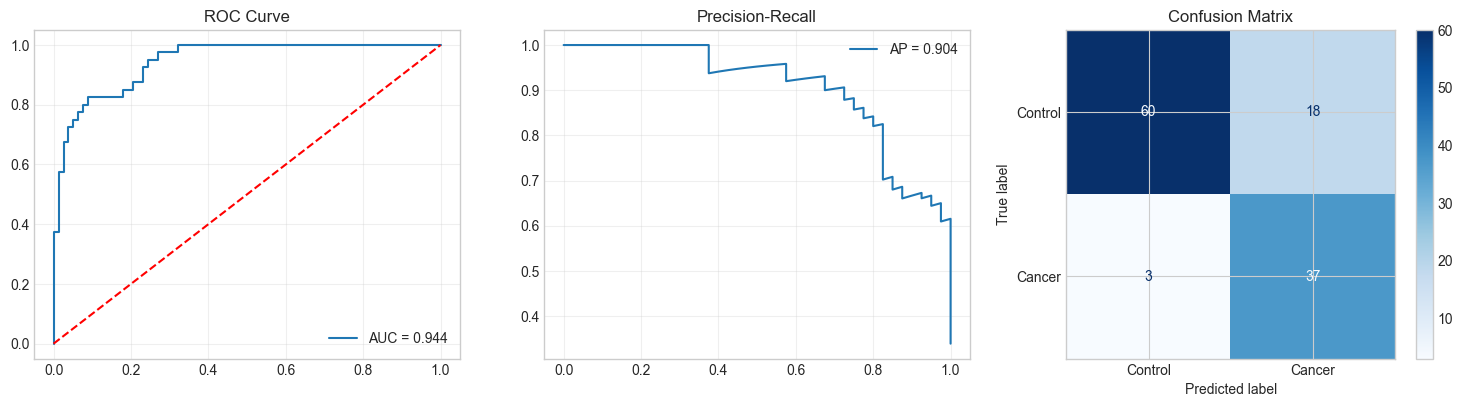

✅ Saved: figures\biomarker_test_plots.png


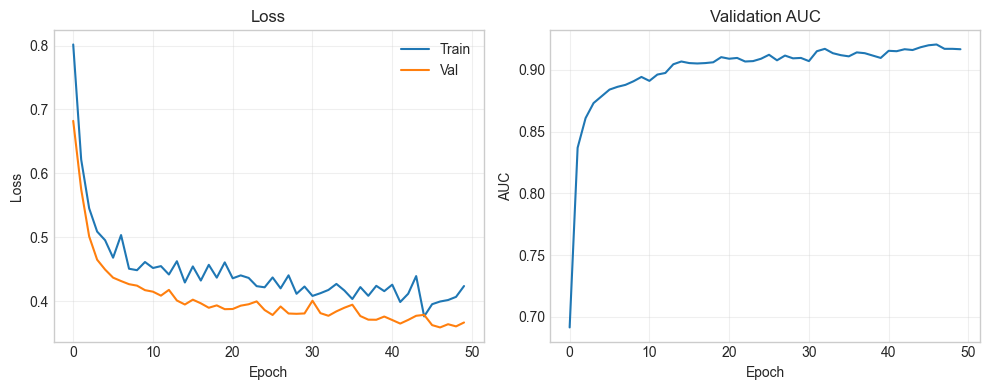

✅ Saved: figures\biomarker_training_curves.png


In [ ]:
# Cell 3.5: Biomarker performance plots (ROC/PR/Confusion + Training Curves)

if not SKIP_BIOMARKER:
    figures_dir = resolve_figures_dir()
    figures_dir.mkdir(parents=True, exist_ok=True)

    # ROC + PR + Confusion (Test)
    fpr, tpr, _ = roc_curve(test_labels, test_probs)
    roc_auc = auc(fpr, tpr)
    prec, rec, _ = precision_recall_curve(test_labels, test_probs)
    pr_auc = auc(rec, prec)
    cm = confusion_matrix(test_labels, test_preds)

    fig, axes = plt.subplots(1, 3, figsize=(15, 4))

    axes[0].plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    axes[0].plot([0, 1], [0, 1], "r--")
    axes[0].set_title("ROC Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(rec, prec, label=f"AP = {pr_auc:.3f}")
    axes[1].set_title("Precision-Recall")
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    disp = ConfusionMatrixDisplay(cm, display_labels=["Control", "Cancer"])
    disp.plot(ax=axes[2], cmap="Blues", values_format="d")
    axes[2].set_title("Confusion Matrix")

    plt.tight_layout()
    out_path = figures_dir / "biomarker_test_plots.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("✅ Saved:", fmt_path(out_path))

    # Training curves
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))

    axes[0].plot(train_losses, label="Train")
    axes[0].plot(val_losses, label="Val")
    axes[0].set_title("Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].plot(val_aucs, label="Val AUC")
    axes[1].set_title("Validation AUC")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("AUC")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    out_path = figures_dir / "biomarker_training_curves.png"
    plt.savefig(out_path, dpi=150)
    plt.show()
    print("✅ Saved:", fmt_path(out_path))

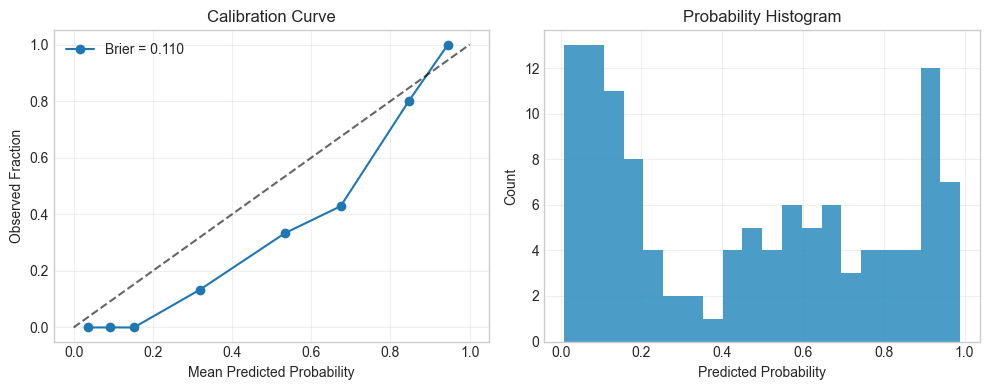

Saved: figures\biomarker_calibration.png


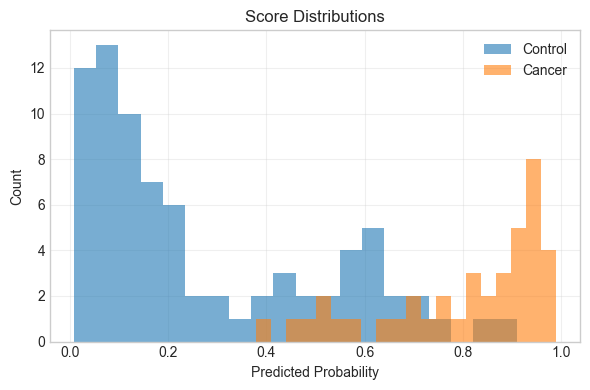

Saved: figures\biomarker_score_distributions.png


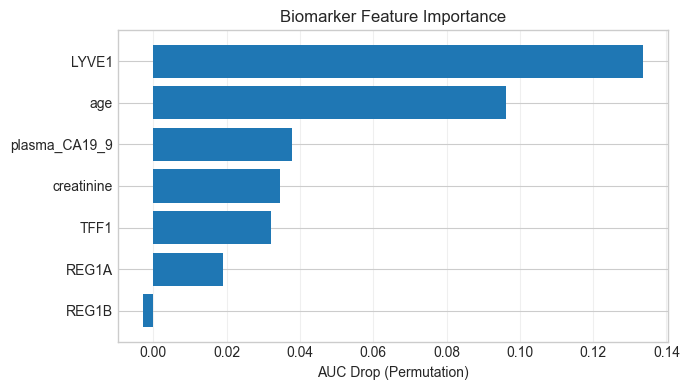

Saved: figures\biomarker_perm_importance.png


In [ ]:
# Cell 3.6: Additional biomarker diagnostics (Calibration + Score Distributions + Permutation Importance)

from src.models import infer_probs

if not SKIP_BIOMARKER:
    from sklearn.calibration import calibration_curve
    from sklearn.metrics import brier_score_loss

    figures_dir = resolve_figures_dir(PROJECT)
    figures_dir.mkdir(parents=True, exist_ok=True)

    bio_model.eval()
    test_probs_np = np.asarray(test_probs)
    test_labels_np = np.asarray(test_labels)

    frac_pos, mean_pred = calibration_curve(test_labels_np, test_probs_np, n_bins=8, strategy="quantile")
    brier = brier_score_loss(test_labels_np, test_probs_np)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    axes[0].plot(mean_pred, frac_pos, marker="o", label=f"Brier = {brier:.3f}")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.6)
    axes[0].set_xlabel("Mean Predicted Probability")
    axes[0].set_ylabel("Observed Fraction")
    axes[0].set_title("Calibration Curve")
    axes[0].legend()
    axes[0].grid(alpha=0.3)

    axes[1].hist(test_probs_np, bins=20, color="#2b8cbe", alpha=0.85)
    axes[1].set_xlabel("Predicted Probability")
    axes[1].set_ylabel("Count")
    axes[1].set_title("Probability Histogram")
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    calib_path = figures_dir / "biomarker_calibration.png"
    plt.savefig(calib_path, dpi=300, bbox_inches="tight")
    plt.show()

    base_auc = roc_auc_score(test_labels_np, test_probs_np)
    perm_importances = []
    for idx, feat in enumerate(available_features):
        X_perm = X_test_bio.copy()
        rng = np.random.default_rng(SEED + idx)
        X_perm[:, idx] = rng.permutation(X_perm[:, idx])
        perm_probs = infer_probs(bio_model, X_perm, device)
        auc_perm = roc_auc_score(test_labels_np, perm_probs)
        perm_importances.append(base_auc - auc_perm)



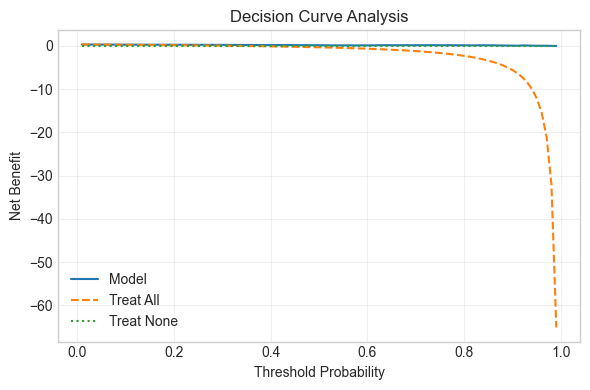

Saved: figures\biomarker_decision_curve.png


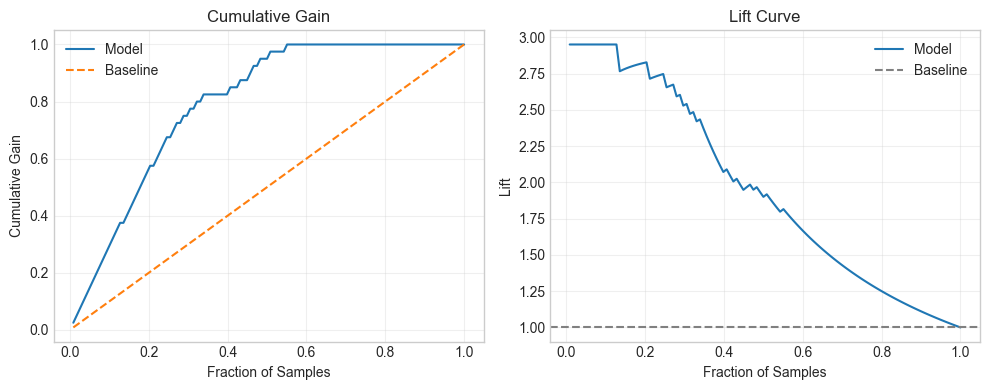

Saved: figures\biomarker_gain_lift.png


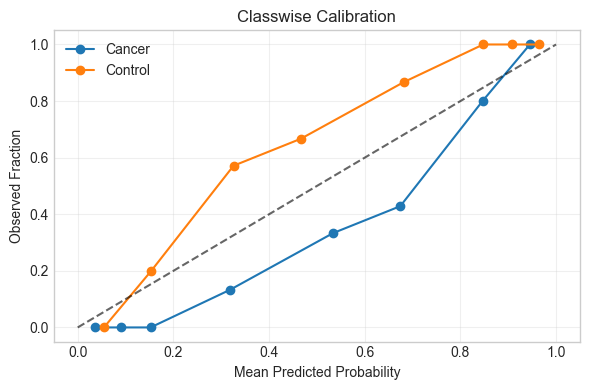

Saved: figures\biomarker_classwise_calibration.png


In [ ]:
# Cell 3.7: Decision Curve + Gain/Lift + Classwise Calibration

if not SKIP_BIOMARKER:
    from sklearn.calibration import calibration_curve

    figures_dir = resolve_figures_dir()
    figures_dir.mkdir(parents=True, exist_ok=True)

    test_probs_np = np.asarray(test_probs)
    test_labels_np = np.asarray(test_labels)

    if len(np.unique(test_labels_np)) < 2:
        print("Skipping extra diagnostics: only one class in test labels.")
    else:
        # Decision curve analysis
        thresholds = np.linspace(0.01, 0.99, 99)
        n = len(test_labels_np)

        def net_benefit(y_true, y_prob, thr):
            preds = (y_prob >= thr).astype(int)
            tp = np.sum((preds == 1) & (y_true == 1))
            fp = np.sum((preds == 1) & (y_true == 0))
            return (tp / n) - (fp / n) * (thr / (1 - thr))

        nb_model = [net_benefit(test_labels_np, test_probs_np, t) for t in thresholds]
        prevalence = np.mean(test_labels_np == 1)
        nb_all = [prevalence - (1 - prevalence) * (t / (1 - t)) for t in thresholds]
        nb_none = np.zeros_like(thresholds)

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(thresholds, nb_model, label="Model")
        ax.plot(thresholds, nb_all, label="Treat All", linestyle="--")
        ax.plot(thresholds, nb_none, label="Treat None", linestyle=":")
        ax.set_xlabel("Threshold Probability")
        ax.set_ylabel("Net Benefit")
        ax.set_title("Decision Curve Analysis")
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        dca_path = figures_dir / "biomarker_decision_curve.png"
        plt.savefig(dca_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fmt_path(dca_path)}")

        # Cumulative gain and lift
        order = np.argsort(test_probs_np)[::-1]
        y_sorted = test_labels_np[order]
        cum_pos = np.cumsum(y_sorted)
        total_pos = max(1, np.sum(y_sorted))
        gains = cum_pos / total_pos
        pct_samples = (np.arange(1, len(y_sorted) + 1) / len(y_sorted))
        lift = gains / np.maximum(pct_samples, 1e-6)

        fig, axes = plt.subplots(1, 2, figsize=(10, 4))
        axes[0].plot(pct_samples, gains, label="Model")
        axes[0].plot(pct_samples, pct_samples, linestyle="--", label="Baseline")
        axes[0].set_xlabel("Fraction of Samples")
        axes[0].set_ylabel("Cumulative Gain")
        axes[0].set_title("Cumulative Gain")
        axes[0].legend()
        axes[0].grid(alpha=0.3)

        axes[1].plot(pct_samples, lift, label="Model")
        axes[1].axhline(1.0, linestyle="--", color="gray", label="Baseline")
        axes[1].set_xlabel("Fraction of Samples")
        axes[1].set_ylabel("Lift")
        axes[1].set_title("Lift Curve")
        axes[1].legend()
        axes[1].grid(alpha=0.3)

        plt.tight_layout()
        gain_path = figures_dir / "biomarker_gain_lift.png"
        plt.savefig(gain_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fmt_path(gain_path)}")

        # Classwise calibration
        frac_pos_p, mean_pred_p = calibration_curve(
            test_labels_np, test_probs_np, n_bins=8, strategy="quantile"
        )
        frac_pos_n, mean_pred_n = calibration_curve(
            1 - test_labels_np, 1 - test_probs_np, n_bins=8, strategy="quantile"
        )

        fig, ax = plt.subplots(figsize=(6, 4))
        ax.plot(mean_pred_p, frac_pos_p, marker="o", label="Cancer")
        ax.plot(mean_pred_n, frac_pos_n, marker="o", label="Control")
        ax.plot([0, 1], [0, 1], "k--", alpha=0.6)
        ax.set_xlabel("Mean Predicted Probability")
        ax.set_ylabel("Observed Fraction")
        ax.set_title("Classwise Calibration")
        ax.legend()
        ax.grid(alpha=0.3)

        plt.tight_layout()
        calib2_path = figures_dir / "biomarker_classwise_calibration.png"
        plt.savefig(calib2_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fmt_path(calib2_path)}")


## Section 3 Summary: Biomarker MLP Results

- Trained a simple MLP (64-32, dropout) on 7 urinary biomarkers: age, plasma_CA19_9, creatinine, LYVE1, REG1B, TFF1, REG1A.
- Used stratified train/val/test splits and class-weighted loss to handle imbalance.
- Reported test metrics (Accuracy, Precision, Recall, F1, AUC) and saved best weights to `models/biomarker_mlp_best.pt`.
- Exported metrics to `reports/biomarker_results.json` and a full set of diagnostics to `figures/` (ROC/PR/CM, calibration, score distributions, permutation importance, decision curves, gain/lift, classwise calibration).

**Notes:**
- Biomarker cohort is independent from CT cohort; results are stand-alone for Phase 3.
- If `SKIP_BIOMARKER=True`, this section is intentionally skipped.

---
## Section 4: Multi-Modal Fusion

**Important Disclosure:** The CT and biomarker datasets are from different patient cohorts, so fusion uses synthetic pairing (matching samples by class).
**Bias caveat (CT):** CT models retain residual domain signal despite mitigation; therefore any fusion results are exploratory and not clinically validated.

**How we report fusion here (to stay defensible):**
- Treat fusion as a *methodology demonstration* (not an externally valid performance claim).
- Always show unimodal baselines (CT-only, biomarker-only) alongside fusion.
- Include sanity checks: repeat synthetic pairing across multiple random seeds and compare against a label-mismatch control to illustrate how sensitive results are to pairing assumptions.

This section demonstrates fusion methodology only.

In [ ]:
# --- Pre-fusion loader: reload checkpoints without retraining ---
# This cell is robust to kernel restarts and reconstructs lightweight inference state.

from pathlib import Path

import torch
from torch.utils.data import DataLoader

from src.models import BiomarkerMLP, build_resnet50_classifier, load_ct_checkpoint
from src.utils import fmt_path

ct_ckpt_path = Path(MODELS_DIR) / "ct_resnet50.pt"
if "model" not in globals():
    if not ct_ckpt_path.exists():
        print(f"[pre-fusion] CT checkpoint not found: {ct_ckpt_path}")
    else:
        model = build_resnet50_classifier(pretrained=False).to(device)
        checkpoint = load_ct_checkpoint(model=model, checkpoint_path=ct_ckpt_path, device=device)
        model.eval()
        print(f"[pre-fusion] Loaded CT model from {checkpoint.path.name}")
else:
    print("[pre-fusion] CT model already in kernel (`model`).")

if "dl_test" not in globals():
    if "ds_test" in globals():
        dl_test = DataLoader(
            ds_test,
            batch_size=int(globals().get("BATCH_SIZE", 16)),
            shuffle=False,
            num_workers=int(globals().get("NUM_WORKERS", 2)),
            pin_memory=(device.type == "cuda"),
        )
        print("[pre-fusion] Rebuilt `dl_test` from existing `ds_test`.")
    else:
        print(
            "[pre-fusion] `dl_test` is missing and `ds_test` is not available. "
            "Run the CT data prep/split cells to create the test dataset/loader."
        )
else:
    print("[pre-fusion] CT test loader already in kernel (`dl_test`).")

bio_ckpt_path = Path(MODELS_DIR) / "biomarker_mlp_best.pt"
if "bio_model" not in globals():
    if bio_ckpt_path.exists() and "available_features" in globals():
        try:
            bio_model = BiomarkerMLP(input_dim=len(available_features)).to(device)
            ckpt_bio = torch.load(bio_ckpt_path, map_location="cpu", weights_only=False)
            state_bio = ckpt_bio.get("model_state_dict", ckpt_bio) if isinstance(ckpt_bio, dict) else ckpt_bio
            if any(k.startswith("module.") for k in state_bio.keys()):
                state_bio = {k.replace("module.", "", 1): v for k, v in state_bio.items()}
            bio_model.load_state_dict(state_bio, strict=False)
            bio_model = bio_model.to(device)
            bio_model.eval()
            print(f"[pre-fusion] Loaded biomarker model from {fmt_path(bio_ckpt_path)}")
        except Exception as exc:
            print(f"[pre-fusion] Biomarker reload skipped (could not load): {exc}")
    else:
        print(
            "[pre-fusion] Biomarker reload skipped (either checkpoint missing or available_features not defined in this kernel)."
        )
else:
    print("[pre-fusion] Biomarker model already in kernel (`bio_model`).")


[pre-fusion] CT model already in kernel (`model`).
[pre-fusion] CT test loader already in kernel (`dl_test`).
[pre-fusion] Biomarker model already in kernel (`bio_model`).


In [ ]:
# Cell 4.1: Decision-Level Fusion (Weighted Average)
# This approach combines predictions from both models and exports a small report/figure.

if not globals().get("SKIP_BIOMARKER", True):
    import matplotlib.pyplot as plt
    import numpy as np

    from src.fusion import collect_ct_probabilities, run_weighted_decision_fusion
    from src.utils import fmt_path, resolve_figures_dir, resolve_reports_dir

    print("=" * 60)
    print("DECISION-LEVEL FUSION")
    print("=" * 60)

    ct_test_probs, ct_test_labels = collect_ct_probabilities(model=model, loader=dl_test, device=device)
    bio_test_probs_arr = np.asarray(test_probs)
    bio_test_labels_arr = np.asarray(test_labels)

    df_decision, paired = run_weighted_decision_fusion(
        ct_probs=ct_test_probs,
        ct_labels=ct_test_labels,
        bio_probs=bio_test_probs_arr,
        bio_labels=bio_test_labels_arr,
        weights=(0.3, 0.5, 0.7),
    )

    fusion_probs_ct = paired["fusion_probs_ct"]
    fusion_probs_bio = paired["fusion_probs_bio"]
    fusion_labels = paired["fusion_labels"]

    for row in df_decision.sort_values("w_ct").to_dict("records"):
        print(f"\nWeights CT={row['w_ct']:.1f}, Bio={row['w_bio']:.1f}:")
        print(f"  Accuracy: {row['acc']:.3f}, F1: {row['f1']:.3f}, AUC: {row['auc']:.3f}")

    reports_dir = resolve_reports_dir(PATHS)
    figures_dir = resolve_figures_dir(PATHS)
    reports_dir.mkdir(parents=True, exist_ok=True)
    figures_dir.mkdir(parents=True, exist_ok=True)

    out_csv = reports_dir / "fusion_decision_level_weights.csv"
    df_decision.to_csv(out_csv, index=False)
    print(f"\nSaved: {fmt_path(out_csv)}")

    fig, ax = plt.subplots(figsize=(5, 3.5))
    ax.plot(df_decision["w_ct"], df_decision["auc"], marker="o")
    ax.set_xlabel("CT weight (w_ct)")
    ax.set_ylabel("AUC")
    ax.set_title("Decision-level fusion (label-matched synthetic pairing)")
    ax.grid(alpha=0.3)
    plt.tight_layout()
    fig_path = figures_dir / "fusion_decision_level_auc_vs_weight.png"
    plt.savefig(fig_path, dpi=300, bbox_inches="tight")
    plt.show()
    print(f"Saved: {fmt_path(fig_path)}")


DECISION-LEVEL FUSION


In [ ]:
# Cell 4.1b: Decision-level fusion sanity checks (multi-seed + label-mismatch control)
# Goal: keep fusion methodological by showing stability across seeds and sensitivity to pairing assumptions.

if not globals().get("SKIP_BIOMARKER", True):
    if ("model" not in globals()) or ("dl_test" not in globals()):
        print("Skipping decision-level fusion sanity checks: CT model/test loader not in kernel.")
    else:
        import matplotlib.pyplot as plt
        import numpy as np

        from src.fusion import collect_ct_probabilities, run_decision_fusion_sanity_check
        from src.utils import fmt_path, resolve_figures_dir, resolve_reports_dir

        reports_dir = resolve_reports_dir(PATHS)
        figures_dir = resolve_figures_dir(PATHS)
        reports_dir.mkdir(parents=True, exist_ok=True)
        figures_dir.mkdir(parents=True, exist_ok=True)

        if not all(name in globals() for name in ["ct_test_probs", "ct_test_labels", "bio_test_probs_arr", "bio_test_labels_arr"]):
            ct_test_probs, ct_test_labels = collect_ct_probabilities(model=model, loader=dl_test, device=device)
            bio_test_probs_arr = np.asarray(test_probs)
            bio_test_labels_arr = np.asarray(test_labels)

        seeds = [SEED, SEED + 1, SEED + 2, SEED + 3, SEED + 4]
        df_fusion_sanity, summary = run_decision_fusion_sanity_check(
            ct_probs=ct_test_probs,
            ct_labels=ct_test_labels,
            bio_probs=bio_test_probs_arr,
            bio_labels=bio_test_labels_arr,
            seeds=seeds,
            weights=(0.3, 0.5, 0.7),
        )

        display(df_fusion_sanity.sort_values(["pairing", "w_ct", "seed"]))
        print("\nSummary (mean+/-std AUC over seeds):")
        display(summary)

        out_full = reports_dir / "fusion_decision_sanity_by_seed.csv"
        out_sum = reports_dir / "fusion_decision_sanity_summary.csv"
        df_fusion_sanity.to_csv(out_full, index=False)
        summary.to_csv(out_sum, index=False)
        print(f"\nSaved: {fmt_path(out_full)}")
        print(f"Saved: {fmt_path(out_sum)}")

        fig, ax = plt.subplots(figsize=(6.5, 3.8))
        for pairing, group in summary.groupby("pairing"):
            ax.errorbar(group["w_ct"], group["auc_mean"], yerr=group["auc_std"], marker="o", capsize=3, label=pairing)
        ax.set_xlabel("CT weight (w_ct)")
        ax.set_ylabel("AUC (mean +/- std over seeds)")
        ax.set_title("Decision-level fusion sanity check")
        ax.grid(alpha=0.3)
        ax.legend()
        plt.tight_layout()
        fig_path = figures_dir / "fusion_decision_sanity_auc.png"
        plt.savefig(fig_path, dpi=300, bbox_inches="tight")
        plt.show()
        print(f"Saved: {fmt_path(fig_path)}")

        print("\nInterpretation guide:")
        print("- If label-mismatch control stays high, fusion is likely dominated by CT bias / leakage signal.")
        print("- If label-mismatch control drops toward ~0.5 AUC while label-matched stays higher, biomarker contributes meaningful signal within the synthetic pairing assumption.")


Skipping decision-level fusion sanity checks: CT model/test loader not in kernel.


In [ ]:
# Cell 4.2: Feature-Level Fusion (Concatenation + MLP)
# Exports: classifier results table (CSV).

from src.fusion import evaluate_feature_level_models, get_ct_embeddings, make_label_matched_fused_dataset

if not globals().get("SKIP_BIOMARKER", True):
    import pandas as pd

    print("\n" + "="*60)
    print("FEATURE-LEVEL FUSION")
    print("="*60)

    ct_emb, ct_lbl = get_ct_embeddings(model, dl_test, device)
    print(f"CT embeddings: {ct_emb.shape}")

    bio_model.eval()
    with torch.no_grad():
        bio_emb = bio_model.extract_features(torch.tensor(X_test_bio, dtype=torch.float32).to(device)).cpu()
    print(f"Bio embeddings: {bio_emb.shape}")

    X_fused, y_fused = make_label_matched_fused_dataset(
        ct_emb=ct_emb,
        ct_lbl=ct_lbl,
        bio_emb=bio_emb,
        bio_lbl=np.asarray(y_test_bio),
        mismatch=False,
        rng=np.random.default_rng(SEED),
    )
    print(f"Fused features: {X_fused.shape}")

    results_df = evaluate_feature_level_models(X_fused, y_fused, random_state=SEED)
    print(results_df)

    reports_dir = resolve_reports_dir(PROJECT)
    reports_dir.mkdir(parents=True, exist_ok=True)
    out_csv = reports_dir / "fusion_feature_level_results.csv"
    results_df.to_csv(out_csv, index=False)
    print(f"\nSaved: {fmt_path(out_csv)}")



In [ ]:
# Cell 4.2b: Feature-level fusion sanity check (label-mismatch control + multi-seed)

from src.fusion import get_ct_embeddings, make_label_matched_fused_dataset

if not globals().get("SKIP_BIOMARKER", True):
    if ("model" not in globals()) or ("dl_test" not in globals()) or ("bio_model" not in globals()) or ("X_test_bio" not in globals()) or ("y_test_bio" not in globals()):
        print("Skipping feature-level fusion sanity checks: required objects not in kernel.")
    else:
        import pandas as pd
        import matplotlib.pyplot as plt
        from sklearn.linear_model import LogisticRegression
        from sklearn.metrics import roc_auc_score, accuracy_score, precision_recall_fscore_support
        from sklearn.model_selection import train_test_split

        reports_dir = resolve_reports_dir(PROJECT)
        figures_dir = resolve_figures_dir(PROJECT)
        reports_dir.mkdir(parents=True, exist_ok=True)
        figures_dir.mkdir(parents=True, exist_ok=True)

        ct_emb, ct_lbl = get_ct_embeddings(model, dl_test, device)
        bio_model.eval()
        with torch.no_grad():
            bio_emb = bio_model.extract_features(torch.tensor(X_test_bio, dtype=torch.float32).to(device)).cpu()
        bio_lbl = np.asarray(y_test_bio)

        def _eval_logreg_auc(X, y, seed):
            X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.3, stratify=y, random_state=seed)
            clf = LogisticRegression(max_iter=2000)
            clf.fit(X_tr, y_tr)
            y_prob = clf.predict_proba(X_te)[:, 1]
            y_pred = (y_prob >= 0.5).astype(int)
            return {
                "auc": float(roc_auc_score(y_te, y_prob)) if len(np.unique(y_te)) > 1 else float("nan"),
                "acc": float(accuracy_score(y_te, y_pred)),
                "f1": float(precision_recall_fscore_support(y_te, y_pred, average="binary", zero_division=0)[2]),
                "n": int(len(y)),
            }

        seeds = [SEED, SEED + 1, SEED + 2, SEED + 3, SEED + 4]
        rows = []
        for s in seeds:
            rng = np.random.default_rng(s)
            for mismatch in [False, True]:
                X, y = make_label_matched_fused_dataset(
                    ct_emb=ct_emb,
                    ct_lbl=ct_lbl,
                    bio_emb=bio_emb,
                    bio_lbl=bio_lbl,
                    mismatch=mismatch,
                    max_per_class=500,
                    rng=rng,
                )
                r = _eval_logreg_auc(X, y, seed=s)
                r["seed"] = int(s)
                r["pairing"] = "label-matched" if not mismatch else "label-mismatch (control)"
                rows.append(r)

        df_feat_sanity = pd.DataFrame(rows)
        out_full = reports_dir / "fusion_feature_sanity_by_seed.csv"
        out_sum = reports_dir / "fusion_feature_sanity_summary.csv"
        df_feat_sanity.to_csv(out_full, index=False)
        summary = df_feat_sanity.groupby(["pairing"], as_index=False).agg(auc_mean=("auc", "mean"), auc_std=("auc", "std"), n_mean=("n", "mean"))
        summary.to_csv(out_sum, index=False)
        print(f"Saved: {fmt_path(out_full)}")
        print(f"Saved: {fmt_path(out_sum)}")



Skipping feature-level fusion sanity checks: required objects not in kernel (model/dl_test/bio_model/X_test_bio/y_test_bio).


### Section 4 Summary (Fusion)

**Short summary**
- Because CT and biomarker cohorts are unpaired, fusion uses label-matched synthetic pairing and is reported as a methodological demonstration, not clinical evidence.
- Decision-level fusion is stable across seeds but remains CT-dominated when CT weight is high; mismatch controls confirm this bias.
- Feature-level fusion collapses to CT-dominated performance (AUC=1.0) even under mismatch controls, highlighting degeneracy.

**Detailed summary**
- **Methodology:** Fusion combines CT ResNet50 outputs and biomarker MLP outputs. Decision-level fusion computes $p_{\mathrm{fused}} = w_{\mathrm{CT}} p_{\mathrm{CT}} + (1-w_{\mathrm{CT}}) p_{\mathrm{Bio}}$ with $w_{\mathrm{CT}} \in \{0.3,0.5,0.7\}$ using label-matched synthetic pairing. Feature-level fusion concatenates 2048-d CT embeddings with 32-d biomarker embeddings and evaluates Logistic Regression and Random Forest classifiers.
- **Decision-level results (label-matched):** AUCs are near-ceiling and stable across seeds (mean AUCs: 0.9977 at $w_{\mathrm{CT}}=0.3$, 0.9994 at 0.5, 0.9997 at 0.7; $n=99$).
- **Decision-level mismatch control:** When labels are intentionally mismatched, AUC collapses at low CT weight (AUC 0.3519 at $w_{\mathrm{CT}}=0.3$) but remains high when CT dominates (AUC 0.9811 at 0.5; 0.9929 at 0.7), demonstrating CT-driven fusion performance.
- **Feature-level results:** Both classifiers reach AUC/Acc/F1 of 1.0 on the synthetic fusion set ($n=30$), and the multi-seed mismatch control also yields AUC=1.0 ($n=118$). This indicates feature-level fusion is fully CT-dominated under the current pairing and sample regime.
- **Interpretation:** High fusion scores do not imply true multimodal complementarity here; they reflect strong CT separability and synthetic pairing constraints. Fusion results are therefore reported as exploratory methodology rather than clinical utility.

---
## Section 5: Summary & Export Results

This section consolidates the final CT, biomarker, and fusion results from saved reports and exports a compact JSON summary and a comparison table without re-running training.

In [6]:
# Cell 5.1: Create comprehensive results summary (load from saved reports if needed)

import json

from src.results import build_final_summary, load_biomarker_metrics, load_ct_metrics, save_json
from src.utils import fmt_path, resolve_reports_dir

print("=" * 70)
print("FINAL RESULTS SUMMARY")
print("=" * 70)

reports_dir = resolve_reports_dir(PATHS)
skip_biomarker = globals().get("SKIP_BIOMARKER", False)

ct_metrics = load_ct_metrics(
    reports_dir=reports_dir,
    in_memory_test_results=globals().get("test_results"),
    in_memory_test_patient=globals().get("test_patient"),
)

bio_metrics = load_biomarker_metrics(
    reports_dir=reports_dir,
    in_memory_metrics=(
        {
            "auc": globals().get("bio_test_auc"),
            "accuracy": globals().get("bio_test_acc"),
            "f1": globals().get("bio_f1"),
        }
        if all(name in globals() for name in ["bio_test_auc", "bio_test_acc", "bio_f1"])
        else None
    ),
)

summary = build_final_summary(
    ct_metrics=ct_metrics,
    skip_biomarker=skip_biomarker,
    bio_metrics=bio_metrics,
    biomarker_features=globals().get("available_features"),
)

out_path = save_json(summary, reports_dir / "final_summary.json")
print(json.dumps(summary, indent=2))
print(f"\nResults saved to {fmt_path(out_path)}")


FINAL RESULTS SUMMARY
{
  "experiment_date": "2026-02-07T20:34:54.222625",
  "ct_model": {
    "architecture": "ResNet50 (global)",
    "preprocessing": "Bias-mitigation + orientation/cropping + ImageNet normalization (see Phase 1/2)",
    "test_metrics": {
      "slice_level": {
        "auc": 0.99989421857864,
        "accuracy": 0.9982920580700256,
        "f1": 0.9927360774818402
      },
      "patient_level": {
        "auc": 1.0,
        "accuracy": 1.0,
        "f1": 1.0
      }
    },
    "source": "final_model_comparison.csv"
  },
  "biomarker_model": {
    "architecture": "MLP (64-32)",
    "features": "unknown",
    "test_metrics": {
      "auc": 0.9439102564102564,
      "accuracy": 0.8220338983050848,
      "f1": 0.7789473684210526
    },
    "source": "biomarker_results.json"
  },
  "fusion_note": "Synthetic pairing used (different patient cohorts). CT retains residual domain signal; fusion results are exploratory and should not be interpreted as clinically validated per

In [7]:
# Cell 5.2: Create comparison table (from saved results if needed)

from src.results import build_model_comparison_table, load_biomarker_metrics, load_ct_metrics
from src.utils import fmt_path, resolve_reports_dir

reports_dir = resolve_reports_dir(PATHS)
skip_biomarker = globals().get("SKIP_BIOMARKER", False)

ct_metrics = globals().get("ct_metrics") or load_ct_metrics(
    reports_dir=reports_dir,
    in_memory_test_results=globals().get("test_results"),
    in_memory_test_patient=globals().get("test_patient"),
)

bio_metrics = globals().get("bio_metrics") or load_biomarker_metrics(
    reports_dir=reports_dir,
    in_memory_metrics=(
        {
            "auc": globals().get("bio_test_auc"),
            "accuracy": globals().get("bio_test_acc"),
            "f1": globals().get("bio_f1"),
        }
        if all(name in globals() for name in ["bio_test_auc", "bio_test_acc", "bio_f1"])
        else None
    ),
)

results_df = build_model_comparison_table(
    ct_metrics=ct_metrics,
    skip_biomarker=skip_biomarker,
    bio_metrics=bio_metrics,
)

print("\n" + "=" * 70)
print("MODEL COMPARISON")
print("=" * 70)
print(results_df.to_string(index=False))

out_path = reports_dir / "model_comparison.csv"
out_path.parent.mkdir(parents=True, exist_ok=True)
results_df.to_csv(out_path, index=False)
print(f"\nSaved to {fmt_path(out_path)}")



MODEL COMPARISON
          Model           Modality   AUC Accuracy    F1                      Note
    CT (Global)          CT Images 1.000    1.000 1.000 Patient-level aggregation
Biomarker (MLP) Urinary Biomarkers 0.944    0.822 0.779      7 biomarker features

Saved to f:\My Drive\Multimodal_Cancer_Detection\reports\model_comparison.csv


---
## Notebook Complete!

**Files saved (key outputs):**
- `models/ct_resnet50.pt` - Best CT classification model (ResNet50 backbone)
- `models/biomarker_mlp_best.pt` - Best biomarker model
- `reports/biomarker_results.json` - Biomarker-only metrics (includes AUC)
- `reports/model_comparison.csv` - Quick comparison table exported in Phase 5
- `reports/final_summary.json` - End-to-end summary JSON
- `reports/fusion_decision_level_weights.csv` - Decision-level fusion (weights sweep)
- `reports/fusion_decision_sanity_by_seed.csv` and `reports/fusion_decision_sanity_summary.csv` - Decision-level fusion sanity checks
- `reports/fusion_feature_level_results.csv` - Feature-level fusion classifier results
- `reports/fusion_feature_sanity_by_seed.csv` and `reports/fusion_feature_sanity_summary.csv` - Feature-level fusion sanity checks
- `figures/fusion_decision_level_auc_vs_weight.png` - Decision-level fusion AUC vs weight
- `figures/fusion_decision_sanity_auc.png` - Decision-level fusion sanity check plot
- `figures/fusion_feature_sanity_auc.png` - Feature-level fusion sanity check plot
- `reports/` and `figures/` - Exported plots, cluster summaries, and explainability figures

**Next steps for dissertation:**
1. Summarize preprocessing + bias-mitigation rationale (Phase 1) with supporting QC figures
2. Report CT results (slice + patient) and cross-domain experiments with confidence intervals
3. Document the fusion setup clearly (synthetic pairing disclosure + repeated runs + mismatch controls)
4. Write limitations and external validity discussion

---